# MZM KAN Variants Comparison

## Overview

Twelve architectures on the same MZM regression problem (8 geometry features
-> BW_3dB / IL / V_pi), no Mixture-of-Experts (see `MZM_MLP.ipynb` /
`MZM_MoE_KAN_Gate_Comparison.ipynb` for that): `MLP5` ("base") plus the
original spline `KAN` plus 10 community/paper KAN variants that each swap
`KANLinear`'s B-spline edge basis for a different one. `KAN` itself is kept
as its own entry (not folded into "the 10 variants") since several of the
variants below -- especially efficient-KAN -- are explicitly framed as a
comparison *against* it, not a replacement for it.

Every architecture is individually bisection-matched to Base MLP5's default
336,253 params (own formula, own `xxx_scale_matching`, mirroring
`MZM_MLP.ipynb`'s own `kan_scale_matching`), and this notebook adds
**training-time and inference-time** as new first-class metrics alongside
the existing parameter-efficiency, bootstrap-variance, and data-efficiency
studies. Given the 12x multiplier on total training runs, the three sweep
studies use **reduced intensity** relative to `MZM_MLP.ipynb`'s own
(fewer scale/fraction points, fewer bootstrap resamples) -- see each
study's own markdown for the exact numbers and the statistical caveat that
comes with them.

| Architecture | Basis / mechanism | Family | Source |
|---|---|---|---|
| `base` (MLP5) | fixed ReLU nonlinearity, linear weights | -- | -- |
| `kan` | order-3 B-splines on a fixed grid | spline | Liu et al. 2024, arXiv:2404.19756 |
| `efficient_kan` | identical math to `kan`, reshaped into one flat matmul | spline | community (e.g. Blealtan/efficient-kan) |
| `multkan` | `kan`'s B-spline edges + explicit multiplication nodes | spline | Liu et al. 2024b ("KAN 2.0"), arXiv:2408.10205 |
| `fastkan` | fixed-center Gaussian RBFs, flattened to one matmul | RBF/bump | Li 2024, arXiv:2405.06721 |
| `fasterkan` | fixed-center RSWAF (`1-tanh^2`) bumps, cheaper than RBF | RBF/bump | community (RSWAF) |
| `relukan` | `[ReLU*ReLU]^2` piecewise-quadratic bumps, no spline recursion | RBF/bump | Qiu et al. 2024, arXiv:2406.02075 |
| `chebykan` | Chebyshev polynomials of the first kind on `tanh(x)` | polynomial | community (e.g. SynodicMonth/ChebyKAN) |
| `rkan` | rational (Safe Padé) functions, pole-free by construction | polynomial | Molina et al. 2020, arXiv:1907.06732 |
| `fourierkan` | truncated Fourier series (learnable cos/sin coefficients) | periodic | community (e.g. GistNoesis/FourierKAN) |
| `sinekan` | learnable shared frequencies, fixed scheduled phases | periodic | Reinhardt & Dai 2024, arXiv:2407.04149 |
| `wavkan` | per-edge learnable Mexican-hat wavelets | wavelet | Bozorgasl & Chen 2024, arXiv:2405.12832 |

**Note on GR-KAN**: an 11th variant was requested (group-rational, from the
"Kolmogorov-Arnold Transformer" line of work) but was dropped -- it's
designed around a Vision Transformer's channel/attention-head structure,
not a standalone dense-regression KAN layer, so it doesn't fit this
notebook's comparison.

## Setup

In [1]:
# ==============================
# Import Required Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import re

from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
import optax
from flax import nnx

# Reproducibility
random_state = 123
np.random.seed(random_state)
import time
import matplotlib.cm as cm

## Model Definitions

### Base MLP

In [2]:
BN_EPS = 1e-5
BN_MOMENTUM = 0.9


class MLP5(nnx.Module):
    """BatchNorm here is plain math over params it only reads (never
    mutates in place), so the whole forward pass is a pure function of
    (params, batch_stats, x)."""

    def __init__(
        self, input_dim=8, output_dim=3, dropout=0.2,
        hidden_dims=(200, 300, 350, 300, 200), *, rngs: nnx.Rngs,
    ):
        he = jax.nn.initializers.he_uniform()
        zeros = jax.nn.initializers.zeros

        def linear(d_in, d_out):
            return nnx.Linear(d_in, d_out, kernel_init=he, bias_init=zeros, rngs=rngs)

        def bn_params(d):
            return (
                nnx.Param(jnp.ones((d,))),
                nnx.Param(jnp.zeros((d,))),
                nnx.BatchStat(jnp.zeros((d,))),
                nnx.BatchStat(jnp.ones((d,))),
            )

        h1, h2, h3, h4, h5 = hidden_dims

        self.fc1 = linear(input_dim, h1)
        self.bn1_scale, self.bn1_bias, self.bn1_mean, self.bn1_var = bn_params(h1)

        self.fc2 = linear(h1, h2)
        self.bn2_scale, self.bn2_bias, self.bn2_mean, self.bn2_var = bn_params(h2)

        self.fc3 = linear(h2, h3)
        self.bn3_scale, self.bn3_bias, self.bn3_mean, self.bn3_var = bn_params(h3)

        self.fc4 = linear(h3, h4)
        self.bn4_scale, self.bn4_bias, self.bn4_mean, self.bn4_var = bn_params(h4)

        self.fc5 = linear(h4, h5)
        self.bn5_scale, self.bn5_bias, self.bn5_mean, self.bn5_var = bn_params(h5)

        self.output = linear(h5, output_dim)

        self.dropout = nnx.Dropout(dropout)

    def _block(self, x, fc, scale, bias, running_mean, running_var, *, train, rngs):
        x = fc(x)
        if train:
            mean = jnp.mean(x, axis=0)
            var = jnp.var(x, axis=0)
        else:
            mean, var = running_mean[...], running_var[...]
        x = (x - mean) / jnp.sqrt(var + BN_EPS) * scale[...] + bias[...]
        x = nnx.relu(x)
        x = self.dropout(x, deterministic=not train, rngs=rngs)
        return x, (mean, var)

    def __call__(self, x, *, train: bool, rngs=None):
        residual = x

        x, s1 = self._block(x, self.fc1, self.bn1_scale, self.bn1_bias, self.bn1_mean, self.bn1_var, train=train, rngs=rngs)
        x, s2 = self._block(x, self.fc2, self.bn2_scale, self.bn2_bias, self.bn2_mean, self.bn2_var, train=train, rngs=rngs)
        x, s3 = self._block(x, self.fc3, self.bn3_scale, self.bn3_bias, self.bn3_mean, self.bn3_var, train=train, rngs=rngs)
        x, s4 = self._block(x, self.fc4, self.bn4_scale, self.bn4_bias, self.bn4_mean, self.bn4_var, train=train, rngs=rngs)
        x, s5 = self._block(x, self.fc5, self.bn5_scale, self.bn5_bias, self.bn5_mean, self.bn5_var, train=train, rngs=rngs)
        batch_stats = {
            "bn1_mean": s1[0], "bn1_var": s1[1],
            "bn2_mean": s2[0], "bn2_var": s2[1],
            "bn3_mean": s3[0], "bn3_var": s3[1],
            "bn4_mean": s4[0], "bn4_var": s4[1],
            "bn5_mean": s5[0], "bn5_var": s5[1],
        }

        if residual.shape[-1] < x.shape[-1]:
            pad = x.shape[-1] - residual.shape[-1]
            residual = jnp.pad(residual, ((0, 0), (0, pad)))
        elif residual.shape[-1] > x.shape[-1]:
            residual = residual[:, : x.shape[-1]]

        x = x + residual

        return self.output(x), batch_stats

### Original spline KAN, and a generic stack

`KANLinear` is unchanged from `MZM_MLP.ipynb`. `KANStack` generalizes that
notebook's own `KAN` class -- it was already exactly this (a plain
`nnx.data([...])` list of edge layers, summed layer by layer) -- into a
reusable wrapper parametrized by *which* edge-layer class to stack, so
every variant below only needs to implement its own `XxxLinear` edge layer
(`__call__(x, *, train, rngs) -> (out, {})`) and gets the multi-layer
composition (Eq. 2.7 in the base KAN paper) for free.

`GRID_RANGE` is the one shared domain convention every fixed/bounded-domain
variant below references (matches `KANLinear`'s own default), so
differences between architectures reflect basis-function choice rather
than each variant inventing its own ad hoc input range. `_bound` is used by
the variants whose basis has no natural saturation of its own (Fourier,
rational, sine) to keep out-of-range test points from aliasing into an
arbitrary phase/value -- splines, RBFs, wavelets, and ReLU-KAN's bumps
don't need it since they already clip/saturate.

In [3]:
GRID_RANGE = (-2.0, 2.0)


def _bound(x):
    """tanh-bound raw input into GRID_RANGE, smoothly saturating for
    inputs outside the training-time range -- periodic (Fourier/Sine) and
    raw-polynomial (rational) bases have no natural saturation of their
    own, unlike splines/RBFs/wavelets."""
    lo, hi = GRID_RANGE
    return lo + (hi - lo) * (jnp.tanh(x) + 1.0) / 2.0


class KANLinear(nnx.Module):
    """A single KAN layer: an n_in x n_out matrix of learnable 1D edge
    functions phi(x) = w_b * silu(x) + w_s * spline(x) (Liu et al. 2024,
    arXiv:2404.19756, Eq. 2.5/2.10-2.12). Unchanged from MZM_MLP.ipynb."""

    def __init__(
        self, in_features, out_features, grid_size=5, spline_order=3,
        grid_range=GRID_RANGE, *, rngs: nnx.Rngs,
    ):
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order
        self.grid_range = grid_range

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = np.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0]
        self.knots = tuple(float(v) for v in grid)

        he = jax.nn.initializers.he_uniform()
        num_basis = grid_size + spline_order
        self.base_weight = nnx.Param(he(rngs.params(), (out_features, in_features)))
        self.spline_scaler = nnx.Param(jnp.ones((out_features, in_features)))
        self.spline_weight = nnx.Param(
            jax.random.normal(rngs.params(), (out_features, in_features, num_basis)) * 0.1
        )

    def _b_splines(self, x):
        knots = jnp.asarray(self.knots, dtype=x.dtype)
        xc = jnp.clip(x, self.grid_range[0], self.grid_range[1])[..., None]
        bases = ((xc >= knots[:-1]) & (xc < knots[1:])).astype(x.dtype)
        for order in range(1, self.spline_order + 1):
            left = (xc - knots[: -order - 1]) / (knots[order:-1] - knots[: -order - 1])
            right = (knots[order + 1:] - xc) / (knots[order + 1:] - knots[1:-order])
            bases = left * bases[..., :-1] + right * bases[..., 1:]
        return bases

    def __call__(self, x, *, train: bool = False, rngs=None):
        base_out = jax.nn.silu(x) @ self.base_weight[...].T
        bases = self._b_splines(x)
        weighted = self.spline_weight[...] * self.spline_scaler[...][..., None]
        spline_out = jnp.einsum("oik,...ik->...o", weighted, bases)
        return base_out + spline_out, {}


class KANStack(nnx.Module):
    """Generic stack of any KAN-style edge layer class: KAN(x) =
    (Phi_{L-1} o ... o Phi_0)(x) (Eq. 2.7), parametrized by which
    edge-layer implementation `layer_cls` to compose over `dims =
    (input_dim, *hidden_dims, output_dim)`."""

    def __init__(self, layer_cls, dims, *, rngs: nnx.Rngs, **layer_kwargs):
        self.layers = nnx.data([
            layer_cls(d_in, d_out, rngs=rngs, **layer_kwargs)
            for d_in, d_out in zip(dims[:-1], dims[1:])
        ])

    def __call__(self, x, *, train: bool = False, rngs=None):
        for layer in self.layers:
            x, _ = layer(x, train=train, rngs=rngs)
        return x, {}

### The 10 variant edge layers

In [4]:
class FastKANLinear(nnx.Module):
    """FastKAN edge layer (Li 2024, arXiv:2405.06721): replaces KANLinear's
    B-spline basis with fixed-center Gaussian RBFs, `rbf_k(x) =
    exp(-((x-c_k)/h)^2)`, flattened into a single matmul ("spline_linear")
    instead of the paper's own per-edge coefficient tensor. Base/residual
    branch kept (mirrors KANLinear's own extrapolation handling). No
    LayerNorm on the input -- the paper uses one to bound activations into
    the RBF grid, but this repo's inputs are already MinMaxScaler-bounded."""

    def __init__(self, in_features, out_features, num_grids=8, *, rngs: nnx.Rngs):
        self.in_features = in_features
        self.out_features = out_features
        self.num_grids = num_grids
        centers = np.linspace(GRID_RANGE[0], GRID_RANGE[1], num_grids)
        self.centers = tuple(float(c) for c in centers)
        self.h = (GRID_RANGE[1] - GRID_RANGE[0]) / max(num_grids - 1, 1)

        he = jax.nn.initializers.he_uniform()
        self.spline_linear = nnx.Param(
            he(rngs.params(), (out_features, in_features * num_grids)) * 0.1
        )
        self.base_weight = nnx.Param(he(rngs.params(), (out_features, in_features)))

    def _rbf(self, x):
        centers = jnp.asarray(self.centers, dtype=x.dtype)
        return jnp.exp(-((x[..., None] - centers) / self.h) ** 2)

    def __call__(self, x, *, train: bool = False, rngs=None):
        base_out = jax.nn.silu(x) @ self.base_weight[...].T
        feats = self._rbf(x).reshape(*x.shape[:-1], self.in_features * self.num_grids)
        spline_out = feats @ self.spline_linear[...].T
        return base_out + spline_out, {}


class EfficientKANLinear(nnx.Module):
    """efficient-KAN edge layer (community reformulation of KANLinear,
    e.g. github.com/Blealtan/efficient-kan): mathematically IDENTICAL to
    KANLinear (same B-spline basis, same base+spline sum, same param
    count) -- the only change is reshaping the per-edge B-spline
    coefficient tensor into a flat matrix so the spline branch is one
    ordinary matmul instead of an einsum over a 3-index tensor. Included
    to empirically test whether that PyTorch-motivated reformulation still
    matters once everything is already fused into one jax.jit-compiled XLA
    program -- under JIT, XLA likely lowers both forms to the same
    `dot_general` HLO, so any speed difference measured in the Timing
    section below is the real answer, not an assumption either way."""

    def __init__(self, in_features, out_features, grid_size=5, spline_order=3,
                 grid_range=GRID_RANGE, *, rngs: nnx.Rngs):
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order
        self.grid_range = grid_range
        self.num_basis = grid_size + spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = np.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0]
        self.knots = tuple(float(v) for v in grid)

        he = jax.nn.initializers.he_uniform()
        self.base_weight = nnx.Param(he(rngs.params(), (out_features, in_features)))
        self.spline_scaler = nnx.Param(jnp.ones((out_features, in_features)))
        self.spline_weight = nnx.Param(
            jax.random.normal(rngs.params(), (out_features, in_features * self.num_basis)) * 0.1
        )

    def _b_splines_flat(self, x):
        knots = jnp.asarray(self.knots, dtype=x.dtype)
        xc = jnp.clip(x, self.grid_range[0], self.grid_range[1])[..., None]
        bases = ((xc >= knots[:-1]) & (xc < knots[1:])).astype(x.dtype)
        for order in range(1, self.spline_order + 1):
            left = (xc - knots[: -order - 1]) / (knots[order:-1] - knots[: -order - 1])
            right = (knots[order + 1:] - xc) / (knots[order + 1:] - knots[1:-order])
            bases = left * bases[..., :-1] + right * bases[..., 1:]
        return bases.reshape(*x.shape[:-1], self.in_features * self.num_basis)

    def __call__(self, x, *, train: bool = False, rngs=None):
        base_out = jax.nn.silu(x) @ self.base_weight[...].T
        bases_flat = self._b_splines_flat(x)
        scaler_flat = jnp.repeat(self.spline_scaler[...], self.num_basis, axis=1)
        weight_eff = self.spline_weight[...] * scaler_flat
        spline_out = bases_flat @ weight_eff.T
        return base_out + spline_out, {}


class ChebyKANLinear(nnx.Module):
    """ChebyKAN edge layer (community project, e.g. github.com/
    SynodicMonth/ChebyKAN): replaces the B-spline basis with Chebyshev
    polynomials of the first kind, `phi(x) = sum_{n=0}^{degree} c_n
    T_n(tanh(x))` (tanh bounds x into [-1,1], Chebyshev's natural domain;
    T_n=2*y*T_{n-1}-T_{n-2}). No base branch -- T_0(x)=1 already supplies a
    bias-like constant term. `c_n` initialized at small std since
    `|T_n(y)| <= 1` on [-1,1]."""

    def __init__(self, in_features, out_features, degree=7, *, rngs: nnx.Rngs):
        self.in_features = in_features
        self.out_features = out_features
        self.degree = degree
        std = 1.0 / (in_features * (degree + 1))
        self.coeffs = nnx.Param(
            jax.random.normal(rngs.params(), (out_features, in_features, degree + 1)) * std
        )

    def _chebyshev(self, y):
        basis = [jnp.ones_like(y), y]
        for _ in range(2, self.degree + 1):
            basis.append(2 * y * basis[-1] - basis[-2])
        return jnp.stack(basis[: self.degree + 1], axis=-1)

    def __call__(self, x, *, train: bool = False, rngs=None):
        y = jnp.tanh(x)
        bases = self._chebyshev(y)
        out = jnp.einsum("oid,...id->...o", self.coeffs[...], bases)
        return out, {}


class FourierKANLinear(nnx.Module):
    """FourierKAN edge layer (community project, e.g. github.com/
    GistNoesis/FourierKAN): replaces the B-spline basis with a truncated
    Fourier series, `phi(x) = a_0 + sum_{k=1}^{K}(a_k*cos(k*x) +
    b_k*sin(k*x))`. Unlike splines/RBFs, cos/sin have no natural
    saturation, so x is `_bound`-ed first -- otherwise an out-of-range
    test input could alias into a completely different phase."""

    def __init__(self, in_features, out_features, gridsize=6, *, rngs: nnx.Rngs):
        self.in_features = in_features
        self.out_features = out_features
        self.gridsize = gridsize
        std = 1.0 / (in_features * (2 * gridsize + 1)) ** 0.5
        self.a0 = nnx.Param(jnp.zeros((out_features, in_features)))
        self.a = nnx.Param(jax.random.normal(rngs.params(), (out_features, in_features, gridsize)) * std)
        self.b = nnx.Param(jax.random.normal(rngs.params(), (out_features, in_features, gridsize)) * std)

    def __call__(self, x, *, train: bool = False, rngs=None):
        y = _bound(x)
        k = jnp.arange(1, self.gridsize + 1, dtype=y.dtype)
        angles = y[..., None] * k
        cos_out = jnp.einsum("oik,...ik->...o", self.a[...], jnp.cos(angles))
        sin_out = jnp.einsum("oik,...ik->...o", self.b[...], jnp.sin(angles))
        const_out = jnp.sum(self.a0[...], axis=1)
        return const_out + cos_out + sin_out, {}


class WavKANLinear(nnx.Module):
    """Wav-KAN edge layer (Bozorgasl & Chen 2024, arXiv:2405.12832,
    simplified to one wavelet family): replaces the B-spline basis with a
    per-edge learnable Mexican-hat wavelet, `phi(x) = weight *
    psi((x-translation)/scale)`, `psi(u) = (1-u^2)*exp(-u^2/2)`, plus a
    base/residual branch. `scale` is parameterized via softplus so it can
    never reach zero/negative, which would blow up or sign-flip
    `(x-translation)/scale` discontinuously under unconstrained gradient
    descent."""

    def __init__(self, in_features, out_features, *, rngs: nnx.Rngs):
        self.in_features = in_features
        self.out_features = out_features
        he = jax.nn.initializers.he_uniform()
        self.base_weight = nnx.Param(he(rngs.params(), (out_features, in_features)))
        self.wave_weight = nnx.Param(he(rngs.params(), (out_features, in_features)))
        self.raw_scale = nnx.Param(jnp.zeros((out_features, in_features)))
        self.translation = nnx.Param(jnp.zeros((out_features, in_features)))

    def __call__(self, x, *, train: bool = False, rngs=None):
        base_out = jax.nn.silu(x) @ self.base_weight[...].T
        scale = jax.nn.softplus(self.raw_scale[...]) + 1e-3
        u = (x[..., None, :] - self.translation[...]) / scale
        psi = (1 - u ** 2) * jnp.exp(-u ** 2 / 2)
        wave_out = jnp.sum(self.wave_weight[...] * psi, axis=-1)
        return base_out + wave_out, {}


class ReLUKANLinear(nnx.Module):
    """ReLU-KAN edge layer (Qiu et al. 2024, arXiv:2406.02075): replaces
    the B-spline basis with `grid_size+k` piecewise-quadratic bump
    functions built purely from ReLU + multiply (no spline recursion,
    GPU/CUDA-friendly): `R_i(x) = [ReLU(e_i-x)*ReLU(x-s_i)]^2 *
    16/(e_i-s_i)^4`, `s_i=(i-k-1)/grid_size`, `e_i=i/grid_size`. Domain is
    [0,1] in the paper -- remapped here from GRID_RANGE, clipped for
    out-of-range test points. No base branch (the paper explicitly drops
    it)."""

    def __init__(self, in_features, out_features, grid_size=5, k=3, *, rngs: nnx.Rngs):
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.k = k
        self.num_basis = grid_size + k
        idx = np.arange(self.num_basis)
        s = (idx - k - 1) / grid_size
        e = idx / grid_size
        self.s = tuple(float(v) for v in s)
        self.e = tuple(float(v) for v in e)
        self.norm = tuple(float(16.0 / (ei - si) ** 4) for si, ei in zip(s, e))

        he = jax.nn.initializers.he_uniform()
        self.weight = nnx.Param(
            he(rngs.params(), (out_features, in_features * self.num_basis)) * 0.5
        )

    def _basis(self, x01):
        s = jnp.asarray(self.s, dtype=x01.dtype)
        e = jnp.asarray(self.e, dtype=x01.dtype)
        norm = jnp.asarray(self.norm, dtype=x01.dtype)
        xc = x01[..., None]
        bump = jax.nn.relu(e - xc) * jax.nn.relu(xc - s)
        return (bump ** 2) * norm

    def __call__(self, x, *, train: bool = False, rngs=None):
        x01 = jnp.clip((x - GRID_RANGE[0]) / (GRID_RANGE[1] - GRID_RANGE[0]), 0.0, 1.0)
        feats = self._basis(x01).reshape(*x.shape[:-1], self.in_features * self.num_basis)
        out = feats @ self.weight[...].T
        return out, {}


class RKANLinear(nnx.Module):
    """rKAN edge layer (Safe Padé Activation Unit basis, Molina et al.
    2020, arXiv:1907.06732, adapted to per-edge KAN functions): `phi(x) =
    P(x)/Q(x)`, `P(x)=sum_{p=0}^m a_p x^p`, `Q(x)=1+|sum_{q=1}^n b_q x^q|`
    (Q>=1 always, so this is pole-free by construction). `x` is
    `_bound`-ed first (raw polynomial terms have no natural saturation).
    Coefficients initialized near-identity (`a_1=1`, everything else 0, so
    `Q` starts at 1) rather than deriving a full variance-preserving
    analysis. Powers computed by direct stacking rather than Horner's
    method, since `m,n` are small (<=3) and `x` is bounded, so numerical
    stability isn't a concern either way -- direct stacking keeps the
    per-edge einsum simpler to read."""

    def __init__(self, in_features, out_features, m=3, n=2, *, rngs: nnx.Rngs):
        self.in_features = in_features
        self.out_features = out_features
        self.m = m
        self.n = n
        a_init = np.zeros((out_features, in_features, m + 1), dtype=np.float32)
        if m >= 1:
            a_init[:, :, 1] = 1.0
        self.a = nnx.Param(jnp.asarray(a_init))
        self.b = nnx.Param(jnp.zeros((out_features, in_features, n)))

    def __call__(self, x, *, train: bool = False, rngs=None):
        y = _bound(x)
        p_powers = jnp.stack([y ** p for p in range(self.m + 1)], axis=-1)
        q_powers = jnp.stack([y ** q for q in range(1, self.n + 1)], axis=-1)
        P = jnp.einsum("oip,...ip->...oi", self.a[...], p_powers)
        Q = 1.0 + jnp.abs(jnp.einsum("oiq,...iq->...oi", self.b[...], q_powers))
        phi = P / Q
        return jnp.sum(phi, axis=-1), {}


class SineKANLinear(nnx.Module):
    """SineKAN edge layer (Reinhardt & Dai 2024, arXiv:2407.04149):
    replaces the B-spline basis with a grid of sine functions with
    LEARNABLE, layer-SHARED frequencies and FIXED phases -- the opposite
    of a naive "amplitude+phase both learnable per edge" guess, which
    would just be a reparametrized FourierKAN: `phi(x) = sum_k A_k *
    sin(omega_k*x + phi_k) + b`. `omega_k` is learnable and shared across
    every edge in the layer (not per-edge); `phi_k` is FIXED via the
    paper's recursive decay schedule `phi_{k+1} = phi_k * R(k)`, `R(k) =
    A*k^-K + C` -- a k-only schedule (not per-input-channel; a pragmatic
    simplification given available detail) that keeps different grid
    components out of phase with each other as depth increases. `x` is
    `_bound`-ed first, same rationale as FourierKAN."""

    _PHASE_A = 0.97241
    _PHASE_K = 0.98844
    _PHASE_C = 0.99945

    def __init__(self, in_features, out_features, gridsize=6, *, rngs: nnx.Rngs):
        self.in_features = in_features
        self.out_features = out_features
        self.gridsize = gridsize

        phases = [1.0]
        for g in range(1, gridsize):
            r = self._PHASE_A * (g ** -self._PHASE_K) + self._PHASE_C
            phases.append(phases[-1] * r)
        self.phases = tuple(float(p) for p in phases)

        std = 1.0 / (in_features * gridsize) ** 0.5
        self.amplitude = nnx.Param(
            jax.random.normal(rngs.params(), (out_features, in_features, gridsize)) * std
        )
        self.omega = nnx.Param(jnp.ones((gridsize,)))
        self.bias = nnx.Param(jnp.zeros((out_features,)))

    def __call__(self, x, *, train: bool = False, rngs=None):
        y = _bound(x)
        phases = jnp.asarray(self.phases, dtype=y.dtype)
        angles = y[..., None] * self.omega[...] + phases
        out = jnp.einsum("oik,...ik->...o", self.amplitude[...], jnp.sin(angles))
        return out + self.bias[...], {}


class FasterKANLinear(nnx.Module):
    """FasterKAN edge layer (RSWAF basis, community project, e.g.
    github.com/AthanasiosDelis/faster-kan): like FastKAN but replaces the
    Gaussian RBF with a cheaper "Reflectional SWitch Activation Function",
    `rswaf_k(x) = 1 - tanh((x-c_k)/h)^2` (no exp, same bump shape,
    comparable cost to a single tanh). Same flatten-to-matmul + base-branch
    structure as FastKAN."""

    def __init__(self, in_features, out_features, num_grids=8, *, rngs: nnx.Rngs):
        self.in_features = in_features
        self.out_features = out_features
        self.num_grids = num_grids
        centers = np.linspace(GRID_RANGE[0], GRID_RANGE[1], num_grids)
        self.centers = tuple(float(c) for c in centers)
        self.h = (GRID_RANGE[1] - GRID_RANGE[0]) / max(num_grids - 1, 1)

        he = jax.nn.initializers.he_uniform()
        self.spline_linear = nnx.Param(
            he(rngs.params(), (out_features, in_features * num_grids)) * 0.1
        )
        self.base_weight = nnx.Param(he(rngs.params(), (out_features, in_features)))

    def _rswaf(self, x):
        centers = jnp.asarray(self.centers, dtype=x.dtype)
        return 1.0 - jnp.tanh((x[..., None] - centers) / self.h) ** 2

    def __call__(self, x, *, train: bool = False, rngs=None):
        base_out = jax.nn.silu(x) @ self.base_weight[...].T
        feats = self._rswaf(x).reshape(*x.shape[:-1], self.in_features * self.num_grids)
        spline_out = feats @ self.spline_linear[...].T
        return base_out + spline_out, {}


class MultKANLinear(nnx.Module):
    """MultKAN edge layer (pragmatic simplification of KAN 2.0's
    multiplication nodes, Liu et al. 2024b, arXiv:2408.10205): same
    B-spline edges as KANLinear, but computes `out_features + n_mult` raw
    per-node aggregates instead of `out_features` (`n_mult =
    round(out_features*mult_ratio)`). The first `out_features - n_mult`
    raw aggregates pass through unchanged as ordinary sum-node outputs;
    the remaining `2*n_mult` are paired up and combined via elementwise
    MULTIPLICATION into `n_mult` mult-node outputs, concatenated back to
    exactly `out_features` outputs -- giving nodes that can represent
    products of incoming functions directly, not just sums (the base KAN
    paper's Eq. 2.5 only ever sums). The to-be-multiplied raw aggregates
    are initialized at a smaller std (0.3x) than the sum-node ones, since
    unbounded multiplication (unlike addition) can blow up activations
    before any gradient step has a chance to shrink it."""

    def __init__(self, in_features, out_features, mult_ratio=0.5,
                 grid_size=5, spline_order=3, grid_range=GRID_RANGE, *, rngs: nnx.Rngs):
        self.in_features = in_features
        self.out_features = out_features
        self.n_mult = max(1, round(out_features * mult_ratio)) if out_features > 1 else 0
        self.n_sum = out_features - self.n_mult
        n_raw = self.n_sum + 2 * self.n_mult
        self.n_raw = n_raw
        self.grid_size = grid_size
        self.spline_order = spline_order
        self.grid_range = grid_range
        self.num_basis = grid_size + spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = np.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0]
        self.knots = tuple(float(v) for v in grid)

        he = jax.nn.initializers.he_uniform()
        self.base_weight = nnx.Param(he(rngs.params(), (n_raw, in_features)))
        self.spline_scaler = nnx.Param(jnp.ones((n_raw, in_features)))
        scale = np.ones((n_raw, 1, 1), dtype=np.float32)
        if self.n_mult > 0:
            scale[self.n_sum:, 0, 0] = 0.3
        raw = jax.random.normal(rngs.params(), (n_raw, in_features, self.num_basis)) * 0.1
        self.spline_weight = nnx.Param(raw * jnp.asarray(scale))

    def _b_splines(self, x):
        knots = jnp.asarray(self.knots, dtype=x.dtype)
        xc = jnp.clip(x, self.grid_range[0], self.grid_range[1])[..., None]
        bases = ((xc >= knots[:-1]) & (xc < knots[1:])).astype(x.dtype)
        for order in range(1, self.spline_order + 1):
            left = (xc - knots[: -order - 1]) / (knots[order:-1] - knots[: -order - 1])
            right = (knots[order + 1:] - xc) / (knots[order + 1:] - knots[1:-order])
            bases = left * bases[..., :-1] + right * bases[..., 1:]
        return bases

    def __call__(self, x, *, train: bool = False, rngs=None):
        base_out = jax.nn.silu(x) @ self.base_weight[...].T
        bases = self._b_splines(x)
        weighted = self.spline_weight[...] * self.spline_scaler[...][..., None]
        spline_out = jnp.einsum("oik,...ik->...o", weighted, bases)
        raw = base_out + spline_out
        sum_part = raw[..., : self.n_sum]
        if self.n_mult > 0:
            mult_in = raw[..., self.n_sum:]
            a = mult_in[..., 0::2]
            b = mult_in[..., 1::2]
            mult_part = a * b
            out = jnp.concatenate([sum_part, mult_part], axis=-1)
        else:
            out = sum_part
        return out, {}

## Data Loading & Preprocessing

In [5]:
# ==============================
# Load and Preprocess Data
# ==============================
# from google.colab import drive
# drive.mount('/content/drive')
# file_path = "/content/drive/MyDrive/MZM Data/Sim_generated_dataset.txt"
file_path = "Sim_generated_dataset.txt"

In [6]:
with open(file_path) as f:
    cleaned = [re.sub(r'[\[\]]', '', line.strip()) for line in f]

df = pd.read_csv(StringIO("\n".join(cleaned)), header=None)
df.columns = [
    "PN_offset", "Bias_V", "Core_width", "P+_width", "N+_width",
    "P_width", "N_width", "Phase_length", "BW_3dB", "IL", "V_pi"
]

# Data cleaning: remove rows with extreme V_pi (>500, <0)
df_cleaned = df[(df['V_pi'] < 500) & (df['V_pi'] > 0)].copy()
print(f"Dataset size after cleaning: {len(df_cleaned)} samples")

# Split features / targets
feature_cols = df_cleaned.columns[:8]
target_cols = df_cleaned.columns[8:]

x = df_cleaned[feature_cols].values
y = df_cleaned[target_cols].values

# Train / test split
x_train_raw, x_test_raw, y_train_raw, y_test_raw = train_test_split(
    x, y, test_size=0.1, random_state=random_state
)

# ==============================
# Scaling (fit on TRAIN only)
# ==============================
scaler_x = MinMaxScaler()  # Features
scaler_y1 = StandardScaler()  # BW_3dB
scaler_y2 = StandardScaler()  # IL
scaler_y3 = StandardScaler()  # V_pi

x_train_scaled = scaler_x.fit_transform(x_train_raw)
y_train_scaled = np.hstack([
    scaler_y1.fit_transform(y_train_raw[:, 0:1]),
    scaler_y2.fit_transform(y_train_raw[:, 1:2]),
    scaler_y3.fit_transform(y_train_raw[:, 2:3]),
])

x_test_scaled = scaler_x.transform(x_test_raw)
y_test_scaled = np.hstack([
    scaler_y1.transform(y_test_raw[:, 0:1]),
    scaler_y2.transform(y_test_raw[:, 1:2]),
    scaler_y3.transform(y_test_raw[:, 2:3]),
])

# Convert to tensors
x_train_t = jnp.asarray(x_train_scaled, dtype=jnp.float32)
y_train_t = jnp.asarray(y_train_scaled, dtype=jnp.float32)
x_test_t  = jnp.asarray(x_test_scaled, dtype=jnp.float32)
y_test_t  = jnp.asarray(y_test_scaled, dtype=jnp.float32)

print(f"Train: {x_train_t.shape[0]} | Test: {x_test_t.shape[0]}")
df_cleaned.describe()

Dataset size after cleaning: 9614 samples
Train: 8652 | Test: 962


,PN_offset,Bias_V,Core_width,P+_width,N+_width,P_width,N_width,Phase_length,BW_3dB,IL,V_pi
count,9.614000e+03,9614.000000,9.614000e+03,9.614000e+03,9.614000e+03,9.614000e+03,9.614000e+03,9614.000000,9614.000000,9614.000000,9614.000000
mean,-4.106982e-09,-5.965076,4.774007e-07,2.584718e-07,2.618829e-07,7.853203e-07,7.904345e-07,0.002285,46.011836,1.577726,33.900601
std,1.272187e-07,2.251585,2.488443e-08,1.315607e-07,1.370419e-07,1.293550e-07,1.313482e-07,0.001030,13.757979,0.896971,31.995194
min,-2.150000e-07,-10.000000,4.050720e-07,4.509540e-08,4.500550e-08,4.510390e-07,4.501570e-07,0.000500,2.256410,0.166187,3.564810
25%,-1.064180e-07,-7.874185,4.613922e-07,1.472730e-07,1.420500e-07,6.774380e-07,6.796328e-07,0.001415,34.923077,0.881409,14.321325
50%,0.000000e+00,-5.819890,4.754365e-07,2.522630e-07,2.602395e-07,7.865730e-07,7.942275e-07,0.002229,44.974359,1.394790,23.757300
75%,9.655928e-08,-4.041150,4.891833e-07,3.689188e-07,3.806483e-07,8.958177e-07,9.036680e-07,0.003167,54.800000,2.162227,41.027525
max,2.150000e-07,-2.250820,6.000000e-07,4.998190e-07,5.000000e-07,1.098400e-06,1.099670e-06,0.005971,74.000000,5.255890,394.839000


## GPU Setup

In [7]:
print(f"JAX devices: {jax.devices()}")
print(f"Using backend: {jax.default_backend()}")
print(f"x_train_t device: {x_train_t.device}")

JAX devices: [CudaDevice(id=0)]
Using backend: gpu
x_train_t device: cuda:0


## Training Function

In [8]:
def train_model(
    model_ctor,  # Callable[[nnx.Rngs], nnx.Module] — builds the model to train
    batch_size=16,
    learning_rate=1e-3,
    weight_decay=0.05,
    betas=(0.9, 0.999),
    n_epoch=100,
    verbose=False,
    trial=None,  # Optuna trial for pruning
    early_stopping_patience=20,
    early_stopping_min_delta=1e-5,
    restore_best_weights=True,
    seed=random_state,
    x_train=None,
    y_train=None,
):
    """
    Build, train and evaluate a model with the given hyperparameters.

    `model_ctor(rngs) -> nnx.Module` builds the model; any architecture is
    supported as long as `model.__call__(x, *, train, rngs=None)` returns
    `(pred, new_stats)`, where `new_stats` is a plain nested dict/int-keyed
    structure whose shape matches `nnx.to_pure_dict(nnx.state(model,
    nnx.BatchStat))` — see MLP5/KAN below for two conforming examples.

    x_train/y_train default to the module-level x_train_t/y_train_t but can be
    overridden (e.g. bootstrap-resampled or subsampled) for the comparison
    studies below; the held-out test set is always x_test_t/y_test_t.

    Each epoch's batches run as a single `jax.lax.scan` under one `jit` call
    instead of a Python loop dispatching one XLA call per batch, and per-split
    evaluation is a single whole-array forward pass instead of a batched loop
    — both avoid host/device round-trips that dominate runtime at this model
    size. Scanning over fixed-size batches means each epoch drops the last
    partial batch (equivalent to `drop_last=True`), which discards at most
    `batch_size - 1` samples per epoch.

    Returns
    -------
    dict with keys:
        'train_loss', 'test_loss',
        'train_history', 'test_history',
        'model_state'
    """
    x_train_data = x_train_t if x_train is None else x_train
    y_train_data = y_train_t if y_train is None else y_train

    # --- Build model ---
    init_key, epoch_key = jax.random.split(jax.random.PRNGKey(seed))
    model = model_ctor(nnx.Rngs(init_key))
    graphdef, params, batch_stats = nnx.split(model, nnx.Param, nnx.BatchStat)

    n_params = sum(p.size for p in jax.tree_util.tree_leaves(params))

    tx = optax.adamw(
        learning_rate, weight_decay=weight_decay, b1=betas[0], b2=betas[1],
    )
    opt_state = tx.init(params)

    def apply_fn(params, batch_stats, x, dropout_key, train):
        m = nnx.merge(graphdef, params, batch_stats)
        dropout_rngs = nnx.Rngs(dropout=dropout_key) if train else None
        pred, new_stats = m(x, train=train, rngs=dropout_rngs)
        if not train:
            return pred, batch_stats
        new_batch_stats = jax.tree_util.tree_map(lambda a: a, batch_stats)
        old_pure = nnx.to_pure_dict(batch_stats)
        blended_pure = jax.tree_util.tree_map(
            lambda old, new: BN_MOMENTUM * old + (1 - BN_MOMENTUM) * new,
            old_pure, new_stats,
        )
        nnx.replace_by_pure_dict(new_batch_stats, blended_pure)
        return pred, new_batch_stats

    def loss_fn(params, batch_stats, x_batch, y_batch, dropout_key):
        pred, new_batch_stats = apply_fn(params, batch_stats, x_batch, dropout_key, True)
        loss = jnp.mean((pred - y_batch) ** 2)
        return loss, new_batch_stats

    def train_step(params, batch_stats, opt_state, x_batch, y_batch, dropout_key):
        (loss, new_batch_stats), grads = jax.value_and_grad(loss_fn, has_aux=True)(
            params, batch_stats, x_batch, y_batch, dropout_key
        )
        updates, opt_state = tx.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, new_batch_stats, opt_state

    n_train = x_train_data.shape[0]
    n_batches = max(n_train // batch_size, 1)

    @jax.jit
    def run_epoch(params, batch_stats, opt_state, perm, drop_key):
        """One full epoch of training as a single scan (one XLA dispatch),
        instead of a Python loop issuing one dispatch per batch."""
        batch_idx = perm[: n_batches * batch_size].reshape(n_batches, batch_size)
        batch_keys = jax.random.split(drop_key, n_batches)

        def step(carry, xs):
            params, batch_stats, opt_state = carry
            idx, key = xs
            x_batch = x_train_data[idx]
            y_batch = y_train_data[idx]
            params, batch_stats, opt_state = train_step(
                params, batch_stats, opt_state, x_batch, y_batch, key
            )
            return (params, batch_stats, opt_state), None

        (params, batch_stats, opt_state), _ = jax.lax.scan(
            step, (params, batch_stats, opt_state), (batch_idx, batch_keys)
        )
        return params, batch_stats, opt_state

    @jax.jit
    def eval_loss(params, batch_stats, x, y):
        pred, _ = apply_fn(params, batch_stats, x, None, False)
        return jnp.mean((pred - y) ** 2)

    train_hist = np.zeros(n_epoch)
    test_hist  = np.zeros(n_epoch)

    # --- Early stopping bookkeeping ---
    best_test_loss = float('inf')
    best_epoch = -1
    epochs_without_improvement = 0
    best_state = None
    stopped_epoch = n_epoch - 1

    # --- Training loop ---
    epoch_iter = tqdm(
        range(n_epoch),
        desc="Training",
        dynamic_ncols=True,
        leave=False,
        colour="cyan",
        disable=not verbose,
    )

    for epoch in epoch_iter:
        epoch_key, perm_key, drop_key = jax.random.split(epoch_key, 3)
        perm = jax.random.permutation(perm_key, n_train)
        params, batch_stats, opt_state = run_epoch(params, batch_stats, opt_state, perm, drop_key)

        # --- Evaluation ---
        train_loss = float(eval_loss(params, batch_stats, x_train_data, y_train_data))
        test_loss = float(eval_loss(params, batch_stats, x_test_t, y_test_t))
        train_hist[epoch] = train_loss
        test_hist[epoch] = test_loss

        if verbose:
            epoch_iter.set_postfix({
                "train": f"{train_loss:.4e}",
                "test": f"{test_loss:.4e}",
                "best": f"{best_test_loss:.4e}" if np.isfinite(best_test_loss) else "inf",
            })

        # Optuna pruning
        if trial is not None:
            trial.report(test_loss, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        # Early stopping (based on test loss)
        if test_loss < (best_test_loss - early_stopping_min_delta):
            best_test_loss = test_loss
            best_epoch = epoch
            epochs_without_improvement = 0
            if restore_best_weights:
                best_state = (params, batch_stats)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= early_stopping_patience:
            stopped_epoch = epoch
            if verbose:
                print(
                    f"Early stopping at epoch {epoch} (best epoch: {best_epoch}, best test: {best_test_loss:.6f})"
                )
            break

    # Keep only executed part of histories
    executed_epochs = stopped_epoch + 1
    train_hist = train_hist[:executed_epochs]
    test_hist = test_hist[:executed_epochs]

    # Restore best weights if requested and available
    if restore_best_weights and best_state is not None:
        params, batch_stats = best_state

    # Re-evaluate final model (restored best if enabled)
    final_train_loss = float(eval_loss(params, batch_stats, x_train_data, y_train_data))
    final_test_loss = float(eval_loss(params, batch_stats, x_test_t, y_test_t))

    return {
        'train_loss': final_train_loss,
        'test_loss':  final_test_loss,
        'best_test_loss': best_test_loss,
        'best_epoch': best_epoch,
        'stopped_epoch': stopped_epoch,
        'train_history': train_hist,
        'test_history':  test_hist,
        'model_state': (graphdef, params, batch_stats),
        'n_params': n_params,
    }

## Timing Function

Two distinct, clearly-labeled timing measurements, since conflating them
would be misleading (`train_model` compiles fresh on every call, and
early stopping makes epoch counts vary architecture to architecture):

- **Practical/end-to-end**: the three sweep studies below wrap their own
  existing `run_config(...)` calls with `time.perf_counter()` (a couple of
  added lines, zero extra training runs) -- this includes that run's own
  JIT compile and its own early-stopping-determined epoch count. It's an
  honest "how long did this actually take" number, not a clean measure of
  per-step architectural efficiency.
- **Controlled micro-benchmark** (`time_model` below): run once per
  architecture at canonical (default) size only, not swept -- warms up
  with one discarded epoch (to exclude compile time), then times
  `n_epoch_time` steady-state epochs as one block, and inference via a
  `jax.jit`-wrapped `fori_loop` (avoiding Python-dispatch overhead
  dominating a sub-millisecond forward pass), for both a training-size
  batch (latency) and the whole test set (throughput). This is what
  actually answers "is efficient-KAN faster than KAN under JIT" --
  measured, not assumed (see efficient-KAN's own docstring above).

In [9]:
def time_model(model_ctor, *, n_epoch_time=20, n_repeat_infer=200,
                n_repeat_infer_testset=50, batch_size=16, seed=123,
                x_train=None, y_train=None):
    """Controlled micro-benchmark for one architecture at a fixed size.
    Mirrors train_model's own build (same apply_fn/run_epoch closures,
    copied here rather than imported since train_model doesn't expose
    them) so the measured code path matches what training actually runs.
    """
    x_train_data = x_train_t if x_train is None else x_train
    y_train_data = y_train_t if y_train is None else y_train

    init_key, epoch_key = jax.random.split(jax.random.PRNGKey(seed))
    model = model_ctor(nnx.Rngs(init_key))
    graphdef, params, batch_stats = nnx.split(model, nnx.Param, nnx.BatchStat)
    n_params = sum(p.size for p in jax.tree_util.tree_leaves(params))

    tx = optax.adamw(1e-3, weight_decay=0.05, b1=0.9, b2=0.999)
    opt_state = tx.init(params)

    def apply_fn(params, batch_stats, x, dropout_key, train):
        m = nnx.merge(graphdef, params, batch_stats)
        dropout_rngs = nnx.Rngs(dropout=dropout_key) if train else None
        pred, new_stats = m(x, train=train, rngs=dropout_rngs)
        if not train:
            return pred, batch_stats
        new_batch_stats = jax.tree_util.tree_map(lambda a: a, batch_stats)
        old_pure = nnx.to_pure_dict(batch_stats)
        blended_pure = jax.tree_util.tree_map(
            lambda old, new: BN_MOMENTUM * old + (1 - BN_MOMENTUM) * new,
            old_pure, new_stats,
        )
        nnx.replace_by_pure_dict(new_batch_stats, blended_pure)
        return pred, new_batch_stats

    def loss_fn(params, batch_stats, x_batch, y_batch, dropout_key):
        pred, new_batch_stats = apply_fn(params, batch_stats, x_batch, dropout_key, True)
        loss = jnp.mean((pred - y_batch) ** 2)
        return loss, new_batch_stats

    def train_step(params, batch_stats, opt_state, x_batch, y_batch, dropout_key):
        (loss, new_batch_stats), grads = jax.value_and_grad(loss_fn, has_aux=True)(
            params, batch_stats, x_batch, y_batch, dropout_key
        )
        updates, opt_state = tx.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, new_batch_stats, opt_state

    n_train = x_train_data.shape[0]
    n_batches = max(n_train // batch_size, 1)

    @jax.jit
    def run_epoch(params, batch_stats, opt_state, perm, drop_key):
        batch_idx = perm[: n_batches * batch_size].reshape(n_batches, batch_size)
        batch_keys = jax.random.split(drop_key, n_batches)

        def step(carry, xs):
            params, batch_stats, opt_state = carry
            idx, key = xs
            x_batch = x_train_data[idx]
            y_batch = y_train_data[idx]
            params, batch_stats, opt_state = train_step(
                params, batch_stats, opt_state, x_batch, y_batch, key
            )
            return (params, batch_stats, opt_state), None

        (params, batch_stats, opt_state), _ = jax.lax.scan(
            step, (params, batch_stats, opt_state), (batch_idx, batch_keys)
        )
        return params, batch_stats, opt_state

    def _next_keys(epoch_key):
        epoch_key, perm_key, drop_key = jax.random.split(epoch_key, 3)
        perm = jax.random.permutation(perm_key, n_train)
        return epoch_key, perm, drop_key

    # --- warm-up: trigger compilation, discard from timing ---
    epoch_key, perm, drop_key = _next_keys(epoch_key)
    params, batch_stats, opt_state = run_epoch(params, batch_stats, opt_state, perm, drop_key)
    jax.block_until_ready(params)

    # --- steady-state training: n_epoch_time consecutive real epochs ---
    t0 = time.perf_counter()
    for _ in range(n_epoch_time):
        epoch_key, perm, drop_key = _next_keys(epoch_key)
        params, batch_stats, opt_state = run_epoch(params, batch_stats, opt_state, perm, drop_key)
    jax.block_until_ready(params)
    per_epoch_s = (time.perf_counter() - t0) / n_epoch_time

    # --- inference timing: jitted fori_loop over n_repeat calls ---
    def make_timed_infer(x):
        @jax.jit
        def timed_infer(params, batch_stats, n_repeat):
            def body(i, acc):
                pred, _ = apply_fn(params, batch_stats, x, None, False)
                return acc + jnp.sum(pred)
            return jax.lax.fori_loop(0, n_repeat, body, 0.0)
        return timed_infer

    x_batch = x_train_data[:batch_size]
    timed_infer_batch = make_timed_infer(x_batch)
    jax.block_until_ready(timed_infer_batch(params, batch_stats, 1))
    t0 = time.perf_counter()
    jax.block_until_ready(timed_infer_batch(params, batch_stats, n_repeat_infer))
    per_batch_infer_s = (time.perf_counter() - t0) / n_repeat_infer

    timed_infer_testset = make_timed_infer(x_test_t)
    jax.block_until_ready(timed_infer_testset(params, batch_stats, 1))
    t0 = time.perf_counter()
    jax.block_until_ready(timed_infer_testset(params, batch_stats, n_repeat_infer_testset))
    per_testset_infer_s = (time.perf_counter() - t0) / n_repeat_infer_testset

    return {
        "n_params": n_params,
        "per_epoch_s": per_epoch_s,
        "per_batch_infer_s": per_batch_infer_s,
        "per_testset_infer_s": per_testset_infer_s,
    }

## Architecture Registry

`ARCHS` holds all 12 architectures' constructors and their bisection-matched
default widths (each individually matched to Base MLP5's 336,253-param
default, mirroring `MZM_MLP.ipynb`'s own `kan_scale_matching` pattern).
Rather than writing out 11 near-identical `xxx_scale_matching`
bisection loops by hand (one per non-base architecture, differing only in
which architecture's params get counted), `_make_scale_matcher(name)`
factors the shared bisection algorithm out once and closes over `name` --
functionally equivalent to 11 separate copies, with one shared
implementation to keep correct.

`ARCH_META` groups the 11 non-base architectures into 5 basis-function
families (spline / RBF-bump / polynomial / periodic / wavelet), each
family sharing one color and its members distinguished by linestyle -- a
flat 12-color palette (e.g. `tab20`) exceeds what's safely distinguishable
in one chart, and several `tab20` pairs are same-hue light/dark steps that
fail a same-hue-adjacent check outright.

In [10]:
ARCHS = {
    "base": {
        "ctor_factory": lambda dims: (lambda rngs: MLP5(
            input_dim=8, output_dim=3, dropout=0.2, hidden_dims=dims, rngs=rngs)),
        "default_dims": (200, 300, 350, 300, 200),
    },
    "kan": {
        "ctor_factory": lambda dims: (lambda rngs: KANStack(
            KANLinear, (8, *dims, 3), grid_size=5, spline_order=3, rngs=rngs)),
        "default_dims": (63, 95, 110, 95, 63),
    },
    "efficient_kan": {
        "ctor_factory": lambda dims: (lambda rngs: KANStack(
            EfficientKANLinear, (8, *dims, 3), grid_size=5, spline_order=3, rngs=rngs)),
        "default_dims": (63, 95, 110, 95, 63),
    },
    "multkan": {
        "ctor_factory": lambda dims: (lambda rngs: KANStack(
            MultKANLinear, (8, *dims, 3), mult_ratio=0.5, grid_size=5, spline_order=3, rngs=rngs)),
        "default_dims": (52, 77, 90, 77, 52),
    },
    "fastkan": {
        "ctor_factory": lambda dims: (lambda rngs: KANStack(
            FastKANLinear, (8, *dims, 3), num_grids=8, rngs=rngs)),
        "default_dims": (67, 100, 117, 100, 67),
    },
    "fasterkan": {
        "ctor_factory": lambda dims: (lambda rngs: KANStack(
            FasterKANLinear, (8, *dims, 3), num_grids=8, rngs=rngs)),
        "default_dims": (67, 100, 117, 100, 67),
    },
    "relukan": {
        "ctor_factory": lambda dims: (lambda rngs: KANStack(
            ReLUKANLinear, (8, *dims, 3), grid_size=5, k=3, rngs=rngs)),
        "default_dims": (71, 106, 124, 106, 71),
    },
    "chebykan": {
        "ctor_factory": lambda dims: (lambda rngs: KANStack(
            ChebyKANLinear, (8, *dims, 3), degree=7, rngs=rngs)),
        "default_dims": (71, 106, 124, 106, 71),
    },
    "rkan": {
        "ctor_factory": lambda dims: (lambda rngs: KANStack(
            RKANLinear, (8, *dims, 3), m=3, n=2, rngs=rngs)),
        "default_dims": (82, 123, 143, 123, 82),
    },
    "fourierkan": {
        "ctor_factory": lambda dims: (lambda rngs: KANStack(
            FourierKANLinear, (8, *dims, 3), gridsize=6, rngs=rngs)),
        "default_dims": (55, 83, 97, 83, 55),
    },
    "sinekan": {
        "ctor_factory": lambda dims: (lambda rngs: KANStack(
            SineKANLinear, (8, *dims, 3), gridsize=6, rngs=rngs)),
        "default_dims": (82, 123, 143, 123, 82),
    },
    "wavkan": {
        "ctor_factory": lambda dims: (lambda rngs: KANStack(
            WavKANLinear, (8, *dims, 3), rngs=rngs)),
        "default_dims": (100, 151, 176, 151, 100),
    },
}

ARCH_ORDER = ["base", "kan", "efficient_kan", "multkan",
              "fastkan", "fasterkan", "relukan",
              "chebykan", "rkan",
              "fourierkan", "sinekan",
              "wavkan"]

ARCH_META = {
    "base":          dict(family="base",     color="#eb6834", ls="-",  label="Base MLP"),
    "kan":           dict(family="spline",   color="#3477eb", ls="-",  label="KAN"),
    "efficient_kan": dict(family="spline",   color="#3477eb", ls="--", label="efficient-KAN"),
    "multkan":       dict(family="spline",   color="#3477eb", ls=":",  label="MultKAN"),
    "fastkan":       dict(family="rbf",      color="#2ca02c", ls="-",  label="FastKAN"),
    "fasterkan":     dict(family="rbf",      color="#2ca02c", ls="--", label="FasterKAN"),
    "relukan":       dict(family="rbf",      color="#2ca02c", ls=":",  label="ReLU-KAN"),
    "chebykan":      dict(family="poly",     color="#9467bd", ls="-",  label="ChebyKAN"),
    "rkan":          dict(family="poly",     color="#9467bd", ls="--", label="rKAN"),
    "fourierkan":    dict(family="periodic", color="#d62728", ls="-",  label="FourierKAN"),
    "sinekan":       dict(family="periodic", color="#d62728", ls="--", label="SineKAN"),
    "wavkan":        dict(family="wavelet",  color="#17becf", ls="-",  label="Wav-KAN"),
}

n_full = x_train_t.shape[0]


def run_config(name="base", *, hidden_dims=None, frac=1.0, bootstrap=False,
                seed=123, n_epoch=60, patience=15):
    """Train architecture `name` on a possibly resampled training set.
    `hidden_dims` is that architecture's scaling knob -- its own 5-tuple
    of hidden widths (same expand-to-peak-then-shrink shape as Base's,
    just at that architecture's own per-edge parameter scale).

    bootstrap=True resamples n_full points WITH replacement (variance
    study); frac<1 draws a smaller subset WITHOUT replacement
    (data-efficiency study).
    """
    rng = np.random.default_rng(seed)
    x_tr, y_tr = x_train_t, y_train_t
    if bootstrap:
        idx = rng.integers(0, n_full, size=n_full)
        x_tr, y_tr = x_tr[idx], y_tr[idx]
    elif frac < 1.0:
        n_sub = max(int(round(n_full * frac)), 32)
        idx = rng.choice(n_full, size=n_sub, replace=False)
        x_tr, y_tr = x_tr[idx], y_tr[idx]

    dims = hidden_dims if hidden_dims is not None else ARCHS[name]["default_dims"]
    model_ctor = ARCHS[name]["ctor_factory"](dims)

    return train_model(
        model_ctor=model_ctor,
        n_epoch=n_epoch,
        early_stopping_patience=patience,
        seed=seed,
        x_train=x_tr,
        y_train=y_tr,
    )


def _extract(results, key):
    return np.array([row[key] for row in results])


def _count_params(name, hidden_dims):
    m = ARCHS[name]["ctor_factory"](hidden_dims)(nnx.Rngs(0))
    _, params, _ = nnx.split(m, nnx.Param, nnx.BatchStat)
    return sum(p.size for p in jax.tree_util.tree_leaves(params))


_SHAPE_TEMPLATE = (200, 300, 350, 300, 200)  # Base's own default shape


def _make_scale_matcher(name):
    def dims_for(s):
        return tuple(max(2, round(d * s)) for d in _SHAPE_TEMPLATE)

    def scale_matching(target_params, lo=0.01, hi=3.0, iters=40):
        _lo, _hi = lo, hi
        for _ in range(iters):
            mid = (_lo + _hi) / 2
            if _count_params(name, dims_for(mid)) < target_params:
                _lo = mid
            else:
                _hi = mid
        s = (_lo + _hi) / 2
        dims = dims_for(s)
        return dims, _count_params(name, dims)

    return scale_matching


SCALE_MATCHERS = {name: _make_scale_matcher(name) for name in ARCH_ORDER if name != "base"}

_base_n = _count_params("base", ARCHS["base"]["default_dims"])
print(f"Default param counts (target: Base's {_base_n}):")
for name in ARCH_ORDER:
    n = _count_params(name, ARCHS[name]["default_dims"])
    print(f"  {name:15s} {n:>7d}  ({(n - _base_n) / _base_n * 100:+.3f}%)")

Default param counts (target: Base's 336253):
  base             336253  (+0.000%)
  kan              335630  (-0.185%)
  efficient_kan    335630  (-0.185%)
  multkan          336150  (-0.031%)
  fastkan          337833  (+0.470%)
  fasterkan        337833  (+0.470%)
  relukan          336968  (+0.213%)
  chebykan         336968  (+0.213%)
  rkan             337512  (+0.374%)
  fourierkan       335881  (-0.111%)
  sinekan          338104  (+0.550%)
  wavkan           337808  (+0.462%)


## Canonical Training Runs

In [11]:
canonical_results = {}
for name in ARCH_ORDER:
    r = run_config(name, n_epoch=100, patience=20, seed=123)
    canonical_results[name] = r
    print(f"{name:15s} n_params={r['n_params']:>7d} "
          f"train_loss={r['train_loss']:.6f} test_loss={r['test_loss']:.6f} "
          f"best_epoch={r['best_epoch']:>3d}/{r['stopped_epoch']:>3d}")

base            n_params= 336253 train_loss=0.028117 test_loss=0.019508 best_epoch= 60/ 80
kan             n_params= 335630 train_loss=0.013973 test_loss=0.006682 best_epoch= 92/ 99
efficient_kan   n_params= 335630 train_loss=0.013646 test_loss=0.006830 best_epoch= 71/ 91
multkan         n_params= 336150 train_loss=0.012533 test_loss=0.006491 best_epoch= 80/ 99
fastkan         n_params= 337833 train_loss=0.016085 test_loss=0.008981 best_epoch= 65/ 85
fasterkan       n_params= 337833 train_loss=0.016559 test_loss=0.009074 best_epoch= 55/ 75
relukan         n_params= 336968 train_loss=0.024900 test_loss=0.016551 best_epoch= 14/ 34
chebykan        n_params= 336968 train_loss=0.101870 test_loss=0.095102 best_epoch=  4/ 24
rkan            n_params= 337512 train_loss=1.002975 test_loss=1.033900 best_epoch=  6/ 26
fourierkan      n_params= 335881 train_loss=1.009506 test_loss=1.032625 best_epoch=  3/ 23
sinekan         n_params= 338104 train_loss=0.032902 test_loss=0.025918 best_epoch= 20/ 40

## Timing (Canonical Size)

A short pilot-calibration step first, purely informational: it measures
per-epoch time for `base` and `kan` and projects a rough total sweep
runtime (using the ~85% of epoch-budget-used-before-early-stopping
observed in `mlp/kan`'s own executed run as the assumption), so there's a
concrete number before committing to the full 168-call sweep below. If it
looks uncomfortably large, the sweep studies' `n_bootstrap`/scale-point
counts can be trimmed further before running them.

In [12]:
print("Pilot calibration (informational -- projects total sweep runtime):")
_pilot_epoch_s = []
for name in ["base", "kan"]:
    t = time_model(ARCHS[name]["ctor_factory"](ARCHS[name]["default_dims"]), n_epoch_time=5)
    _pilot_epoch_s.append(t["per_epoch_s"])
    print(f"  {name}: per_epoch_s={t['per_epoch_s']:.4f}")

_avg_epoch_s = float(np.mean(_pilot_epoch_s))
_n_sweep_calls_per_arch = 4 + 5 + 4  # param-eff + bootstrap + data-eff (reduced intensity)
_n_arch = len(ARCH_ORDER)
_assumed_budget_frac = 0.85  # observed fraction of epoch budget used before early stopping
_projected_s = _avg_epoch_s * _assumed_budget_frac * (
    100 * _n_arch  # canonical runs, 100-epoch budget
    + 60 * _n_arch * _n_sweep_calls_per_arch  # sweep runs, 60-epoch budget
)
print(f"\nProjected total sweep runtime (rough): ~{_projected_s / 60:.1f} minutes "
      f"({_n_arch} architectures x (1 canonical + {_n_sweep_calls_per_arch} sweep calls))")

Pilot calibration (informational -- projects total sweep runtime):
  base: per_epoch_s=0.1657
  kan: per_epoch_s=0.1963

Projected total sweep runtime (rough): ~27.1 minutes (12 architectures x (1 canonical + 13 sweep calls))


In [13]:
timing_results = {}
for name in ARCH_ORDER:
    ctor = ARCHS[name]["ctor_factory"](ARCHS[name]["default_dims"])
    timing_results[name] = time_model(ctor)
    t = timing_results[name]
    print(f"{name:15s} n_params={t['n_params']:>7d} "
          f"per_epoch_ms={t['per_epoch_s'] * 1000:8.2f} "
          f"per_batch_infer_us={t['per_batch_infer_s'] * 1e6:8.2f} "
          f"per_testset_infer_ms={t['per_testset_infer_s'] * 1000:8.3f}")

base            n_params= 336253 per_epoch_ms=  162.70 per_batch_infer_us=   63.62 per_testset_infer_ms=   0.564
kan             n_params= 335630 per_epoch_ms=  196.95 per_batch_infer_us=  128.11 per_testset_infer_ms=   0.927
efficient_kan   n_params= 335630 per_epoch_ms=  191.42 per_batch_infer_us=  125.81 per_testset_infer_ms=   0.911
multkan         n_params= 336150 per_epoch_ms=  197.89 per_batch_infer_us=  137.85 per_testset_infer_ms=   0.839
fastkan         n_params= 337833 per_epoch_ms=  162.32 per_batch_infer_us=  113.32 per_testset_infer_ms=   0.759
fasterkan       n_params= 337833 per_epoch_ms=  164.03 per_batch_infer_us=  112.28 per_testset_infer_ms=   0.755
relukan         n_params= 336968 per_epoch_ms=  121.61 per_batch_infer_us=   81.25 per_testset_infer_ms=   0.650
chebykan        n_params= 336968 per_epoch_ms=  116.26 per_batch_infer_us=   83.41 per_testset_infer_ms=   0.655
rkan            n_params= 337512 per_epoch_ms=  446.39 per_batch_infer_us=  225.02 per_testset_i

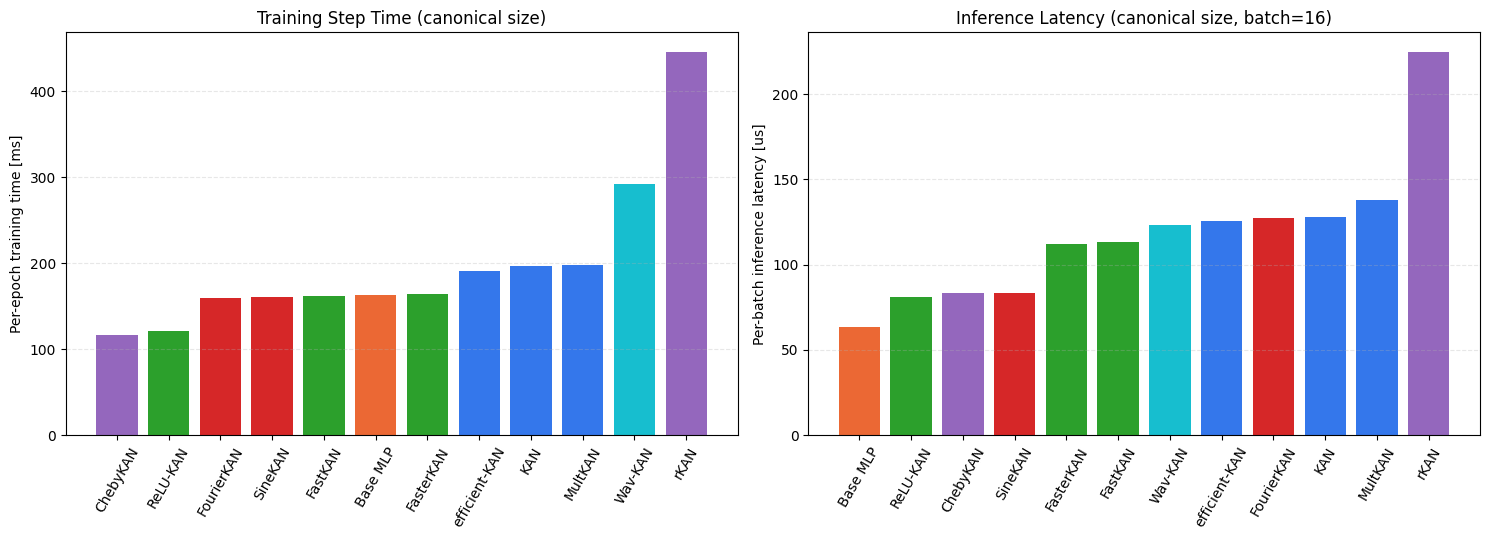

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5.5))

order = sorted(ARCH_ORDER, key=lambda n: timing_results[n]["per_epoch_s"])
colors = [ARCH_META[n]["color"] for n in order]
labels = [ARCH_META[n]["label"] for n in order]

axs[0].bar(labels, [timing_results[n]["per_epoch_s"] * 1000 for n in order], color=colors)
axs[0].set_ylabel("Per-epoch training time [ms]")
axs[0].set_title("Training Step Time (canonical size)")
axs[0].tick_params(axis="x", rotation=60)
axs[0].grid(True, linestyle="--", alpha=0.3, axis="y")

order_infer = sorted(ARCH_ORDER, key=lambda n: timing_results[n]["per_batch_infer_s"])
colors_infer = [ARCH_META[n]["color"] for n in order_infer]
labels_infer = [ARCH_META[n]["label"] for n in order_infer]

axs[1].bar(labels_infer, [timing_results[n]["per_batch_infer_s"] * 1e6 for n in order_infer], color=colors_infer)
axs[1].set_ylabel("Per-batch inference latency [us]")
axs[1].set_title("Inference Latency (canonical size, batch=16)")
axs[1].tick_params(axis="x", rotation=60)
axs[1].grid(True, linestyle="--", alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## Architecture Comparison

The same three studies as `MZM_MLP.ipynb` -- parameter efficiency,
bootstrap variance, data efficiency -- extended from 2 to 12 architectures,
plus the training/inference timing above as a new first-class metric.
Given the 12x multiplier on total training calls, each study below runs at
**reduced intensity** relative to `MZM_MLP.ipynb`'s own (fewer sweep
points / bootstrap resamples) -- see each study's own markdown for the
exact numbers and, for the bootstrap study, an explicit statistical
caveat. Every sweep call is also wrapped in `time.perf_counter()` for a
free "practical wall-time" plot per study (distinct from the controlled
`time_model` benchmark above -- see the Timing Function markdown for why
these two numbers are kept separate).

Total: 12 architectures x (1 canonical + 4 param-sweep + 5 bootstrap + 4
data-eff) = 168 training calls, order-of-magnitude comparable to (~2.8x)
`mlp/kan`'s own already-executed 60-call run.

In [15]:
def plot_small_multiples(results, xkey, ykey, xlabel, ylabel, title, log_x=True, log_y=True):
    """3x4 grid, one panel per architecture (matches ARCH_ORDER exactly),
    each panel showing that architecture's own sweep curve plus Base
    overlaid as a faint dashed reference -- the standard fallback once a
    series count (12 here) exceeds what one overlaid chart can carry
    legibly."""
    fig, axes = plt.subplots(3, 4, figsize=(18, 11))
    axes = axes.flatten()
    base_x = _extract(results["base"], xkey)
    base_y = _extract(results["base"], ykey)
    base_order = np.argsort(base_x)
    for ax, name in zip(axes, ARCH_ORDER):
        meta = ARCH_META[name]
        if name != "base":
            ax.plot(base_x[base_order], base_y[base_order], color=ARCH_META["base"]["color"],
                     lw=1.5, linestyle="--", alpha=0.5, label="Base")
        x = _extract(results[name], xkey)
        y = _extract(results[name], ykey)
        order = np.argsort(x)
        ax.plot(x[order], y[order], color=meta["color"], lw=2, linestyle=meta["ls"],
                 marker="o", markersize=4, label=meta["label"])
        if log_x:
            ax.set_xscale("log")
        if log_y:
            ax.set_yscale("log")
        ax.set_title(meta["label"], fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.legend(fontsize=7)
    fig.suptitle(title)
    fig.supxlabel(xlabel)
    fig.supylabel(ylabel)
    plt.tight_layout()
    plt.show()


def plot_overlay(results, xkey, ykey, xlabel, ylabel, title, log_x=True, log_y=True):
    """Secondary 'big picture' overlay of all 12 architectures on one
    axes, legend outside the plot area, ordered/grouped by family."""
    fig, ax = plt.subplots(figsize=(9, 6))
    for name in ARCH_ORDER:
        meta = ARCH_META[name]
        x = _extract(results[name], xkey)
        y = _extract(results[name], ykey)
        order = np.argsort(x)
        ax.plot(x[order], y[order], color=meta["color"], lw=2, linestyle=meta["ls"],
                 marker="o", markersize=4, label=meta["label"])
    if log_x:
        ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

### 1. Parameter Efficiency

Scale every hidden layer of `MLP5` by a common factor and compare test
loss vs. parameter count. At each Base scale point, every other
architecture's dims are re-matched via its own `SCALE_MATCHERS[name]` to
Base's *actual measured* `n_params` at that point, so the x-axis compares
architectures at equal capacity throughout. **Reduced to 4 scale points**
(`[1.0, 0.5, 0.25, 0.1]`, was 7 in `MZM_MLP.ipynb`) given the 12x
architecture multiplier.

In [16]:
base_dims = np.array([200, 300, 350, 300, 200])
scale_factors = [1.0, 0.5, 0.25, 0.1]

param_results = {name: [] for name in ARCH_ORDER}
for scale in tqdm(scale_factors, desc="Parameter sweep"):
    dims = tuple(int(max(4, round(d * scale))) for d in base_dims)
    t0 = time.perf_counter()
    r_base = run_config("base", hidden_dims=dims, seed=123)
    wall_s = time.perf_counter() - t0
    param_results["base"].append({
        "scale": scale, "hidden_dims": dims, "wall_s": wall_s,
        "n_params": r_base["n_params"], "test_loss": r_base["test_loss"], "train_loss": r_base["train_loss"],
    })

    for name in ARCH_ORDER:
        if name == "base":
            continue
        dims_i, _ = SCALE_MATCHERS[name](r_base["n_params"])
        t0 = time.perf_counter()
        r = run_config(name, hidden_dims=dims_i, seed=123)
        wall_s = time.perf_counter() - t0
        param_results[name].append({
            "scale": scale, "hidden_dims": dims_i, "wall_s": wall_s,
            "n_params": r["n_params"], "test_loss": r["test_loss"], "train_loss": r["train_loss"],
        })

for name in ARCH_ORDER:
    for row in param_results[name]:
        print(f"{name:15s} scale={row['scale']:.2f} n_params={row['n_params']:>7d} test_loss={row['test_loss']:.5f}")

Parameter sweep:   0%|          | 0/4 [00:00<?, ?it/s]

base            scale=1.00 n_params= 336253 test_loss=0.02407
base            scale=0.50 n_params=  85628 test_loss=0.02369
base            scale=0.25 n_params=  22267 test_loss=0.02637
base            scale=0.10 n_params=   3928 test_loss=0.04523
kan             scale=1.00 n_params= 335630 test_loss=0.00768
kan             scale=0.50 n_params=  85300 test_loss=0.00677
kan             scale=0.25 n_params=  22400 test_loss=0.00720
kan             scale=0.10 n_params=   3720 test_loss=0.00987
efficient_kan   scale=1.00 n_params= 335630 test_loss=0.00766
efficient_kan   scale=0.50 n_params=  85300 test_loss=0.00678
efficient_kan   scale=0.25 n_params=  22400 test_loss=0.00720
efficient_kan   scale=0.10 n_params=   3720 test_loss=0.00987
multkan         scale=1.00 n_params= 336150 test_loss=0.00716
multkan         scale=0.50 n_params=  85170 test_loss=0.00651
multkan         scale=0.25 n_params=  22870 test_loss=0.00778
multkan         scale=0.10 n_params=   3750 test_loss=0.01109
fastkan 

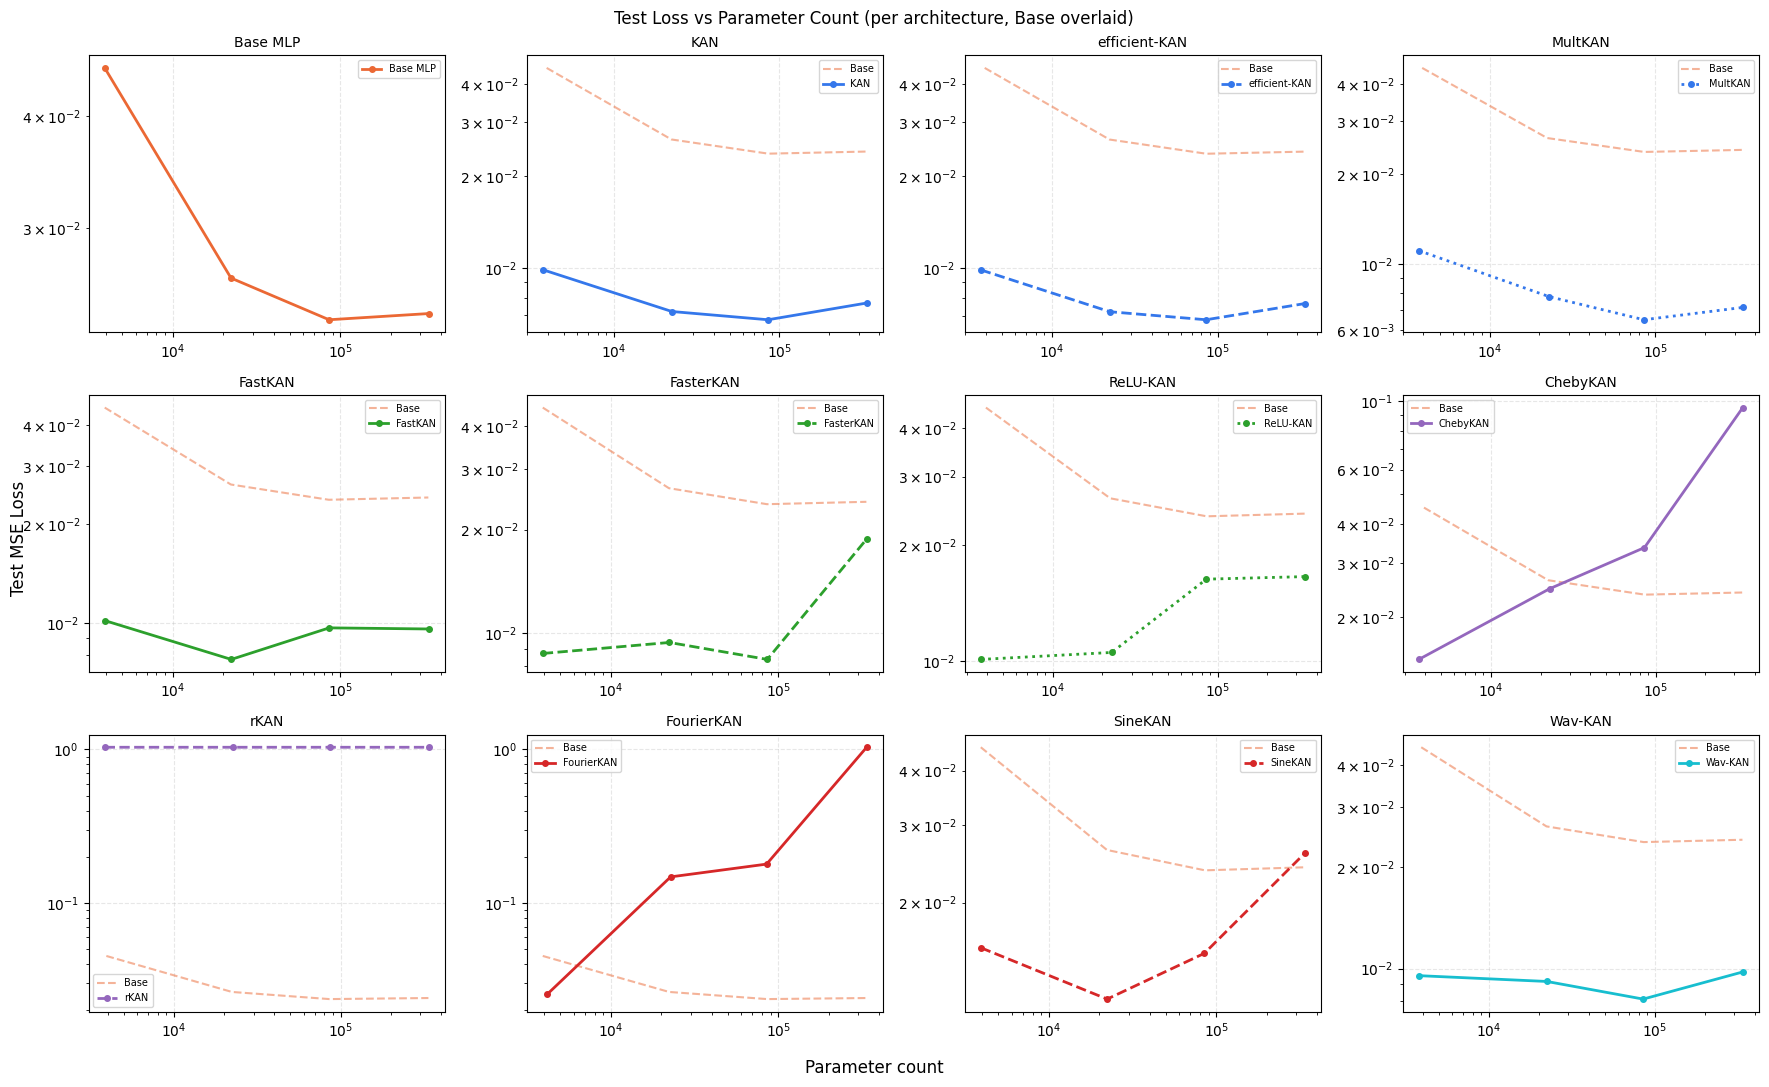

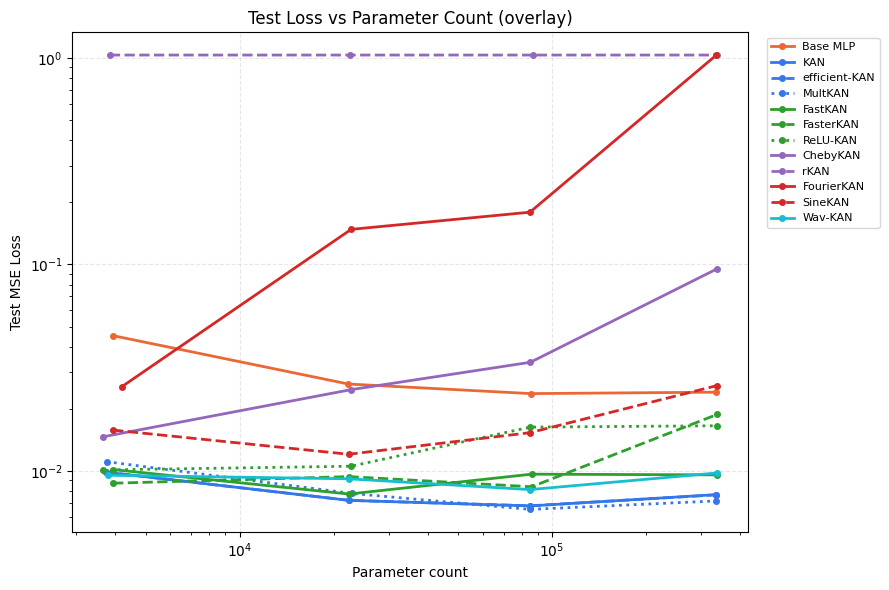

base           : 336253 -> 22267 params (93% fewer) within 20% of full-size test loss
kan            : 335630 -> 22400 params (93% fewer) within 20% of full-size test loss
efficient_kan  : 335630 -> 22400 params (93% fewer) within 20% of full-size test loss
multkan        : 336150 -> 22870 params (93% fewer) within 20% of full-size test loss
fastkan        : 337833 -> 3933 params (99% fewer) within 20% of full-size test loss
fasterkan      : 337833 -> 3933 params (99% fewer) within 20% of full-size test loss
relukan        : 336968 -> 3656 params (99% fewer) within 20% of full-size test loss
chebykan       : 336968 -> 3656 params (99% fewer) within 20% of full-size test loss
rkan           : 337512 -> 3840 params (99% fewer) within 20% of full-size test loss
fourierkan     : 335881 -> 4186 params (99% fewer) within 20% of full-size test loss
sinekan        : 338104 -> 3934 params (99% fewer) within 20% of full-size test loss
wavkan         : 337808 -> 3800 params (99% fewer) within 20%

In [17]:
plot_small_multiples(param_results, "n_params", "test_loss",
                     "Parameter count", "Test MSE Loss",
                     "Test Loss vs Parameter Count (per architecture, Base overlaid)")
plot_overlay(param_results, "n_params", "test_loss",
             "Parameter count", "Test MSE Loss", "Test Loss vs Parameter Count (overlay)")

tolerance = 1.2
for name in ARCH_ORDER:
    full_loss = param_results[name][0]["test_loss"]
    full_params = param_results[name][0]["n_params"]
    within = [row for row in param_results[name] if row["test_loss"] <= tolerance * full_loss]
    smallest = min(within, key=lambda row: row["n_params"])
    reduction = 1 - smallest["n_params"] / full_params
    print(f"{name:15s}: {full_params} -> {smallest['n_params']} params "
          f"({reduction * 100:.0f}% fewer) within 20% of full-size test loss")

### 2. Estimate Variance (Bootstrap)

Retrain each architecture at its *default* dims on bootstrap resamples of
the training set (same size, sampled with replacement), different seed
each time. **Reduced to `n_bootstrap=5`** (was 15) given the 12x
architecture multiplier -- this is statistically coarse: the standard
error of a sample-std estimate scales roughly as `1/sqrt(2(n-1))`, ~35%
relative uncertainty at n=5, so the printed `mean +/- std` below is a
coarse ranking signal across architectures, not a number to lean on for
"architecture A is significantly more variable than B." Primary output is
the sorted summary table (legible regardless of series count); the
box/strip plot is a secondary visual complement.

In [27]:
n_bootstrap = 15

variance_results = {name: [] for name in ARCH_ORDER}
for i in tqdm(range(n_bootstrap), desc="Bootstrap"):
    seed = 1000 + i
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n_full, size=n_full)
    x_tr, y_tr = x_train_t[idx], y_train_t[idx]
    for name in ARCH_ORDER:
        t0 = time.perf_counter()
        r = run_config(name, seed=seed, bootstrap=True)
        wall_s = time.perf_counter() - t0
        variance_results[name].append({
            "seed": seed, "test_loss": r["test_loss"], "train_loss": r["train_loss"],
            "wall_s": wall_s,
        })

print(f"{'architecture':15s} {'mean':>10s} {'std':>10s} {'n':>4s}")
_variance_rows = []
for name in ARCH_ORDER:
    losses = _extract(variance_results[name], "test_loss")
    _variance_rows.append((name, losses.mean(), losses.std()))
for name, mean, std in sorted(_variance_rows, key=lambda r: r[1]):
    print(f"{name:15s} {mean:10.5f} {std:10.5f} {n_bootstrap:4d}")

Bootstrap:   0%|          | 0/15 [00:00<?, ?it/s]

architecture          mean        std    n
kan                0.00778    0.00087   15
efficient_kan      0.00783    0.00089   15
multkan            0.00791    0.00140   15
wavkan             0.01032    0.00190   15
fastkan            0.01096    0.00191   15
fasterkan          0.01119    0.00177   15
relukan            0.01926    0.00293   15
base               0.02176    0.00201   15
sinekan            0.02596    0.00879   15
chebykan           0.18362    0.23264   15
fourierkan         0.99789    0.05282   15
rkan               1.03437    0.00056   15


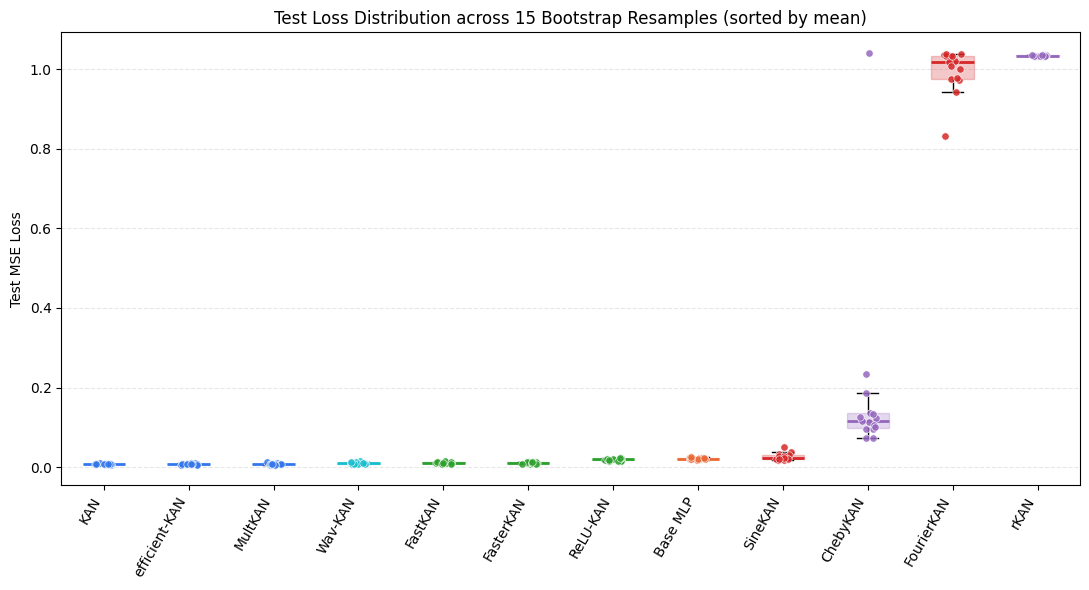

In [29]:
fig, ax = plt.subplots(figsize=(11, 6))

order = [name for name, _, _ in sorted(_variance_rows, key=lambda r: r[1])]
data_box = [[row["test_loss"] for row in variance_results[name]] for name in order]
colors = [ARCH_META[name]["color"] for name in order]
labels = [ARCH_META[name]["label"] for name in order]

bp = ax.boxplot(data_box, positions=range(len(order)), widths=0.5, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.25)
    patch.set_edgecolor(color)
for median, color in zip(bp["medians"], colors):
    median.set_color(color)
    median.set_linewidth(2)

rng_jitter = np.random.default_rng(0)
for pos, name, color in zip(range(len(order)), order, colors):
    ys = [row["test_loss"] for row in variance_results[name]]
    xs = pos + rng_jitter.uniform(-0.1, 0.1, size=len(ys))
    ax.scatter(xs, ys, color=color, s=28, alpha=0.85, edgecolors="white", linewidth=0.5, zorder=3)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(labels, rotation=60, ha="right")
ax.set_ylabel("Test MSE Loss")
ax.set_title(f"Test Loss Distribution across {n_bootstrap} Bootstrap Resamples (sorted by mean)")
ax.grid(True, linestyle="--", alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

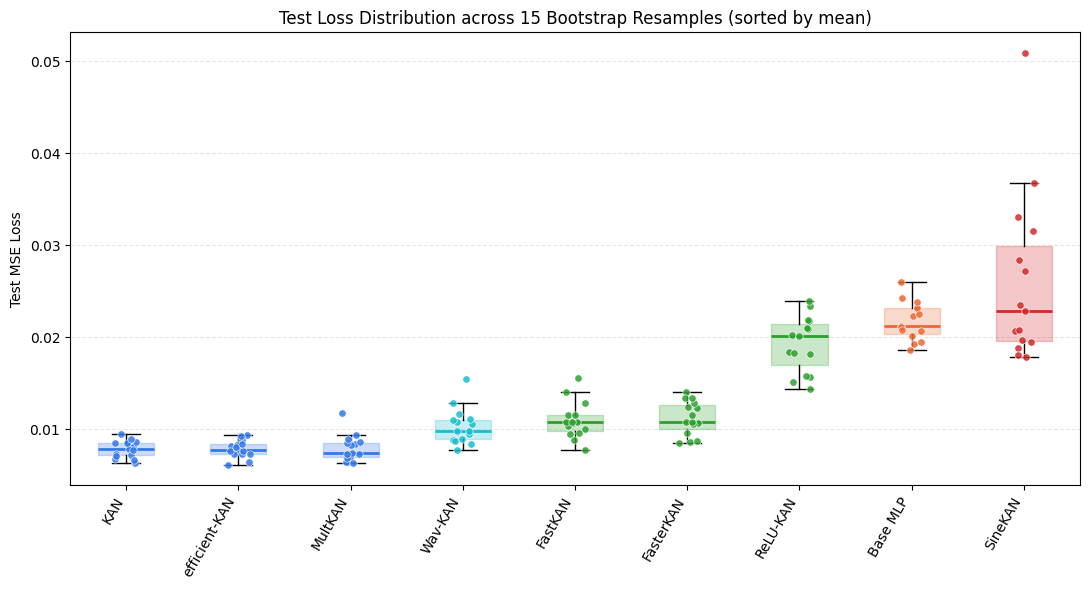

In [33]:
fig, ax = plt.subplots(figsize=(11, 6))

order = [name for name, _, _ in sorted(_variance_rows, key=lambda r: r[1])][:-3]
data_box = [[row["test_loss"] for row in variance_results[name]] for name in order]
colors = [ARCH_META[name]["color"] for name in order]
labels = [ARCH_META[name]["label"] for name in order]

bp = ax.boxplot(data_box, positions=range(len(order)), widths=0.5, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.25)
    patch.set_edgecolor(color)
for median, color in zip(bp["medians"], colors):
    median.set_color(color)
    median.set_linewidth(2)

rng_jitter = np.random.default_rng(0)
for pos, name, color in zip(range(len(order)), order, colors):
    ys = [row["test_loss"] for row in variance_results[name]]
    xs = pos + rng_jitter.uniform(-0.1, 0.1, size=len(ys))
    ax.scatter(xs, ys, color=color, s=28, alpha=0.85, edgecolors="white", linewidth=0.5, zorder=3)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(labels, rotation=60, ha="right")
ax.set_ylabel("Test MSE Loss")
ax.set_title(f"Test Loss Distribution across {n_bootstrap} Bootstrap Resamples (sorted by mean)")
ax.grid(True, linestyle="--", alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### 3. Data Efficiency

Subsample the training set (without replacement) to a range of sizes,
evaluate on the same held-out test set, at each architecture's default
dims. **Reduced to 4 fractions** (`[1.0, 0.5, 0.25, 0.0625]`, was 7 in
`MZM_MLP.ipynb`) given the 12x architecture multiplier -- the last gap is
uneven (skips 0.125) to trade spacing evenness for wider dynamic range.

In [20]:
data_fractions = [1.0, 0.5, 0.25, 0.0625]

data_results = {name: [] for name in ARCH_ORDER}
for frac in tqdm(data_fractions, desc="Data efficiency"):
    for name in ARCH_ORDER:
        t0 = time.perf_counter()
        r = run_config(name, frac=frac, seed=123)
        wall_s = time.perf_counter() - t0
        data_results[name].append({
            "frac": frac, "n_train": int(round(frac * n_full)), "wall_s": wall_s,
            "test_loss": r["test_loss"], "train_loss": r["train_loss"],
        })

for name in ARCH_ORDER:
    for row in data_results[name]:
        print(f"{name:15s} n_train={row['n_train']:>5d} ({row['frac'] * 100:5.1f}%) test_loss={row['test_loss']:.5f}")

Data efficiency:   0%|          | 0/4 [00:00<?, ?it/s]

base            n_train= 8652 (100.0%) test_loss=0.02407
base            n_train= 4326 ( 50.0%) test_loss=0.02873
base            n_train= 2163 ( 25.0%) test_loss=0.03907
base            n_train=  541 (  6.2%) test_loss=0.07516
kan             n_train= 8652 (100.0%) test_loss=0.00768
kan             n_train= 4326 ( 50.0%) test_loss=0.01049
kan             n_train= 2163 ( 25.0%) test_loss=0.01860
kan             n_train=  541 (  6.2%) test_loss=0.02627
efficient_kan   n_train= 8652 (100.0%) test_loss=0.00766
efficient_kan   n_train= 4326 ( 50.0%) test_loss=0.01074
efficient_kan   n_train= 2163 ( 25.0%) test_loss=0.02284
efficient_kan   n_train=  541 (  6.2%) test_loss=0.02882
multkan         n_train= 8652 (100.0%) test_loss=0.00716
multkan         n_train= 4326 ( 50.0%) test_loss=0.00862
multkan         n_train= 2163 ( 25.0%) test_loss=0.01562
multkan         n_train=  541 (  6.2%) test_loss=0.03895
fastkan         n_train= 8652 (100.0%) test_loss=0.00957
fastkan         n_train= 4326 (

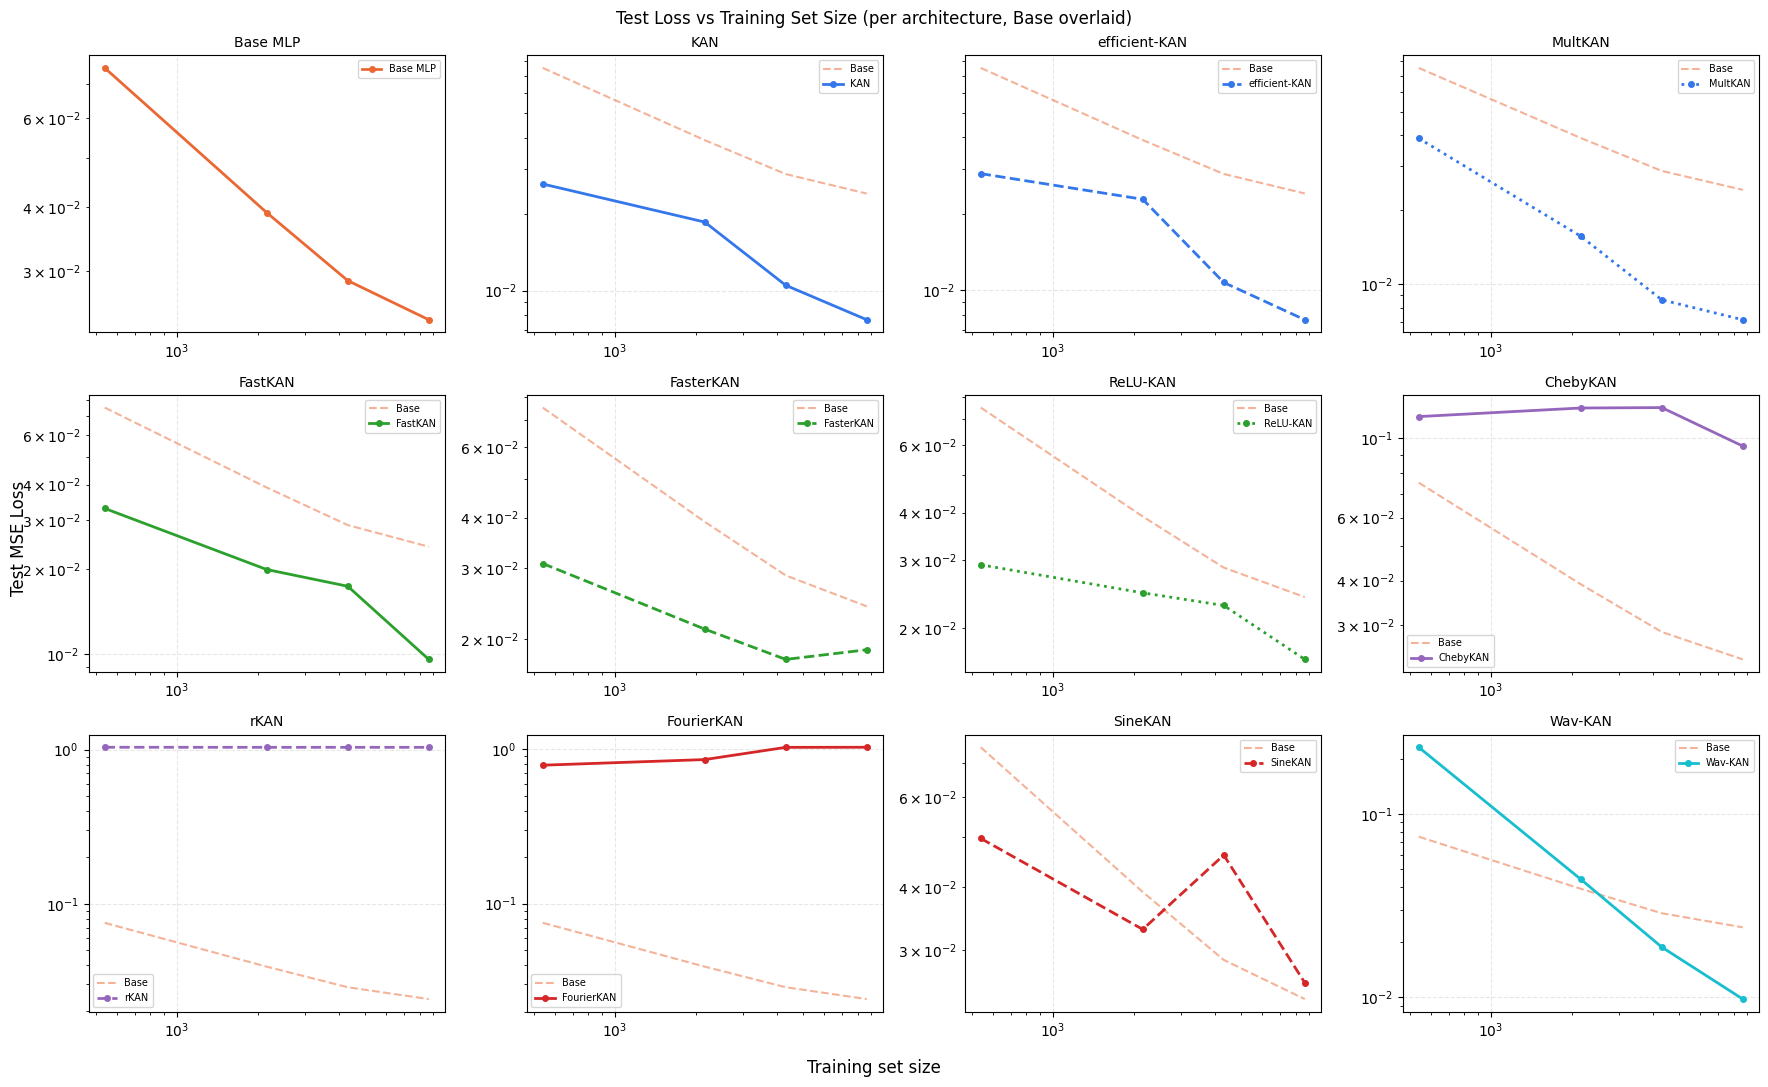

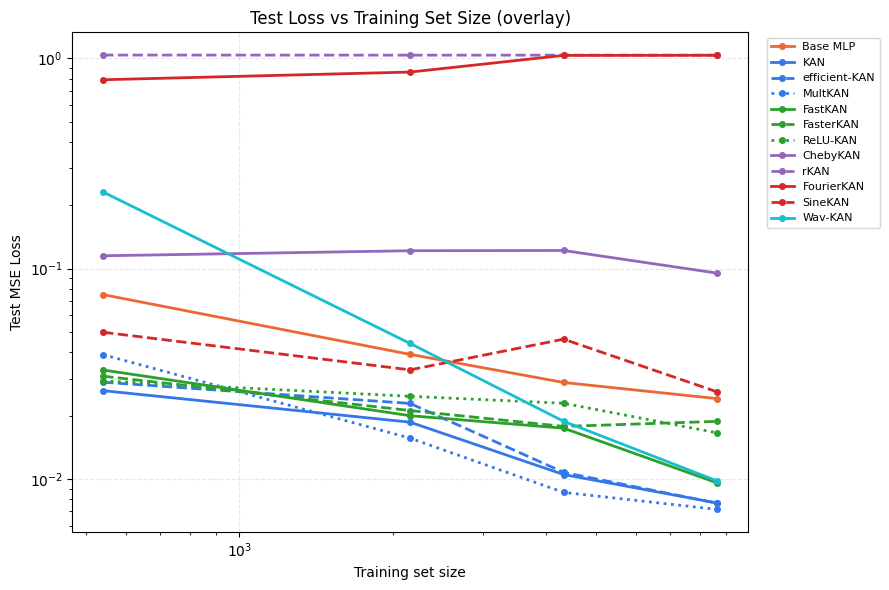

base           : 8652 -> 4326 samples (50% fewer) within 20% of full-data test loss
kan            : 8652 -> 8652 samples (0% fewer) within 20% of full-data test loss
efficient_kan  : 8652 -> 8652 samples (0% fewer) within 20% of full-data test loss
multkan        : 8652 -> 8652 samples (0% fewer) within 20% of full-data test loss
fastkan        : 8652 -> 8652 samples (0% fewer) within 20% of full-data test loss
fasterkan      : 8652 -> 2163 samples (75% fewer) within 20% of full-data test loss
relukan        : 8652 -> 8652 samples (0% fewer) within 20% of full-data test loss
chebykan       : 8652 -> 8652 samples (0% fewer) within 20% of full-data test loss
rkan           : 8652 -> 541 samples (94% fewer) within 20% of full-data test loss
fourierkan     : 8652 -> 541 samples (94% fewer) within 20% of full-data test loss
sinekan        : 8652 -> 8652 samples (0% fewer) within 20% of full-data test loss
wavkan         : 8652 -> 8652 samples (0% fewer) within 20% of full-data test loss


In [21]:
plot_small_multiples(data_results, "n_train", "test_loss",
                     "Training set size", "Test MSE Loss",
                     "Test Loss vs Training Set Size (per architecture, Base overlaid)")
plot_overlay(data_results, "n_train", "test_loss",
             "Training set size", "Test MSE Loss", "Test Loss vs Training Set Size (overlay)")

tolerance = 1.2
for name in ARCH_ORDER:
    full_loss = data_results[name][0]["test_loss"]
    full_n = data_results[name][0]["n_train"]
    within = [row for row in data_results[name] if row["test_loss"] <= tolerance * full_loss]
    smallest = min(within, key=lambda row: row["n_train"])
    reduction = 1 - smallest["n_train"] / full_n
    print(f"{name:15s}: {full_n} -> {smallest['n_train']} samples "
          f"({reduction * 100:.0f}% fewer) within 20% of full-data test loss")

### Summary

In [37]:
print("1) Parameter efficiency (smallest model within 20% of full-size test loss):")
for name in ARCH_ORDER:
    full_loss = param_results[name][0]["test_loss"]
    full_params = param_results[name][0]["n_params"]
    within = [row for row in param_results[name] if row["test_loss"] <= 1.2 * full_loss]
    smallest = min(within, key=lambda row: row["n_params"])
    reduction = 1 - smallest["n_params"] / full_params
    print(f"  {name:15s}: {full_params} -> {smallest['n_params']} params ({reduction * 100:.0f}% fewer)")

print()
print(f"2) Estimate variance (bootstrap, n={n_bootstrap}, coarse -- see caveat above):")
for name, mean, std in sorted(_variance_rows, key=lambda r: r[1]):
    print(f"  {name:15s}: test_loss = {mean:.5f} +/- {std:.5f} (std/mean = {std / mean * 100:.1f}%)")

print()
print("3) Data efficiency (smallest training set within 20% of full-data test loss):")
for name in ARCH_ORDER:
    full_loss = data_results[name][0]["test_loss"]
    full_n = data_results[name][0]["n_train"]
    within = [row for row in data_results[name] if row["test_loss"] <= 1.2 * full_loss]
    smallest = min(within, key=lambda row: row["n_train"])
    reduction = 1 - smallest["n_train"] / full_n
    print(f"  {name:15s}: {full_n} -> {smallest['n_train']} samples ({reduction * 100:.0f}% fewer)")

print()
print("4) Training / inference time at canonical size (sorted fastest-to-slowest):")
for name in sorted(ARCH_ORDER, key=lambda n: timing_results[n]["per_epoch_s"]):
    t = timing_results[name]
    print(f"  {name:15s}: n_params={t['n_params']:>7d} "
          f"per_epoch={t['per_epoch_s'] * 1000:7.2f}ms "
          f"per_batch_infer={t['per_batch_infer_s'] * 1e6:7.2f}us "
          f"per_testset_infer={t['per_testset_infer_s'] * 1000:7.3f}ms")

1) Parameter efficiency (smallest model within 20% of full-size test loss):
  base           : 336253 -> 22267 params (93% fewer)
  kan            : 335630 -> 22400 params (93% fewer)
  efficient_kan  : 335630 -> 22400 params (93% fewer)
  multkan        : 336150 -> 22870 params (93% fewer)
  fastkan        : 337833 -> 3933 params (99% fewer)
  fasterkan      : 337833 -> 3933 params (99% fewer)
  relukan        : 336968 -> 3656 params (99% fewer)
  chebykan       : 336968 -> 3656 params (99% fewer)
  rkan           : 337512 -> 3840 params (99% fewer)
  fourierkan     : 335881 -> 4186 params (99% fewer)
  sinekan        : 338104 -> 3934 params (99% fewer)
  wavkan         : 337808 -> 3800 params (99% fewer)

2) Estimate variance (bootstrap, n=15, coarse -- see caveat above):
  kan            : test_loss = 0.00778 +/- 0.00087 (std/mean = 11.2%)
  efficient_kan  : test_loss = 0.00783 +/- 0.00089 (std/mean = 11.4%)
  multkan        : test_loss = 0.00791 +/- 0.00140 (std/mean = 17.6%)
  wav

In [ ]:
import dill

del axs, fig

dill.dump_session("mzm_kan_variants_comparison.pkl")